# 10 Years of Deep Learning in NLP: A Beginner's Journey

## From Words to ChatGPT - Understanding 50 Key Concepts That Changed AI

---

**Welcome!** This notebook will take you on a visual, hands-on journey through the most important breakthroughs in Natural Language Processing (NLP) over the past decade. We'll build intuition with gentle explanations and code you can run yourself.

---

## What You'll Learn

```
Chapter 1: The Basics          Chapter 2: Sequential Models     Chapter 3: Transformers
├── Tokenization               ├── RNNs                         ├── Self-Attention
└── Word Embeddings            ├── LSTMs & GRUs                 ├── Multi-Head Attention
                               ├── Encoder-Decoder              ├── Positional Encoding
                               └── Attention Mechanism          └── Full Architecture

Chapter 4: Large Language Models                  Chapter 5: Human Alignment
├── GPT (Decoder-only)                            ├── Hallucination Problem
├── BERT (Encoder-only)                           ├── InstructGPT & RLHF
├── XLNet & T5                                    └── ChatGPT & GPT-4
└── LoRA & Knowledge Distillation
```

## Visual Roadmap: The Evolution of NLP

```
    2013          2014          2015          2017          2018          2019          2022-23
      │             │             │             │             │             │             │
      ▼             ▼             ▼             ▼             ▼             ▼             ▼
  ┌───────┐    ┌───────┐    ┌───────┐    ┌───────┐    ┌───────┐    ┌───────┐    ┌───────┐
  │Word2Vec│───▶│  RNN  │───▶│ LSTM  │───▶│Transf.│───▶│ BERT  │───▶│ GPT-2 │───▶│ChatGPT│
  │       │    │Seq2Seq│    │  GRU  │    │  +    │    │       │    │       │    │ GPT-4 │
  │       │    │       │    │       │    │Attn.  │    │       │    │       │    │       │
  └───────┘    └───────┘    └───────┘    └───────┘    └───────┘    └───────┘    └───────┘
      │             │             │             │             │             │             │
      ▼             ▼             ▼             ▼             ▼             ▼             ▼
   Words as      Process       Remember       Process       Understand    Generate      Helpful
   Vectors       Sequences     Long-term      in Parallel   Context       Text          Assistant
```

## Prerequisites

**Don't worry if you're new!** This notebook is designed for beginners. You should have:

- Basic Python knowledge (variables, loops, functions)
- High school math (we'll explain everything else!)
- Curiosity about how AI understands language

**What we'll provide:**
- Visual explanations for every concept
- Step-by-step code you can modify and experiment with
- Gentle math with intuitive explanations
- Real examples you can relate to

## Setup

Let's install and import everything we need. Run this cell first!

In [ ]:
# Install required packages (uncomment if running in Colab)
# !pip install torch numpy matplotlib seaborn plotly transformers tiktoken --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set beautiful plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# For reproducibility
np.random.seed(42)

print("✅ Setup complete! Let's begin our journey through NLP history.")

✅ Setup complete! Let's begin our journey through NLP history.


---

# Chapter 1: The Basics of Language Modeling

## How Do Computers "Read" Text?

Before we can teach computers to understand language, we need to solve a fundamental problem:

> **Computers only understand numbers, not words!**

So our first task is to convert human language into numbers. This happens in two steps:

1. **Tokenization**: Split text into small pieces (tokens)
2. **Embeddings**: Convert each token into a meaningful number vector

```
  "Hello world"  ───▶  ["Hello", "world"]  ───▶  [[0.2, -0.5, ...], [0.8, 0.1, ...]]
       │                      │                            │
    Raw Text              Tokens                    Number Vectors
```

---

## 1.1 Tokenization: Breaking Text Into Pieces

### What is Tokenization?

**Tokenization** is the process of splitting raw text into smaller units called **tokens**. Think of it like breaking a sentence into its building blocks.

### Why Do We Need It?

- Computers can't process raw text strings directly
- We need discrete units to build a vocabulary
- Different tokenization methods capture different patterns

### Three Levels of Tokenization

```
                          "I love cats!"
                               │
           ┌───────────────────┼───────────────────┐
           ▼                   ▼                   ▼
      CHARACTER            WORD              SUBWORD
           │                   │                   │
  ['I',' ','l','o',      ['I','love',        ['I','love',
   'v','e',' ','c',       'cats','!']         'cat','s','!']
   'a','t','s','!']            │                   │
           │              Good for              Modern
      Very long!          English              Standard
```

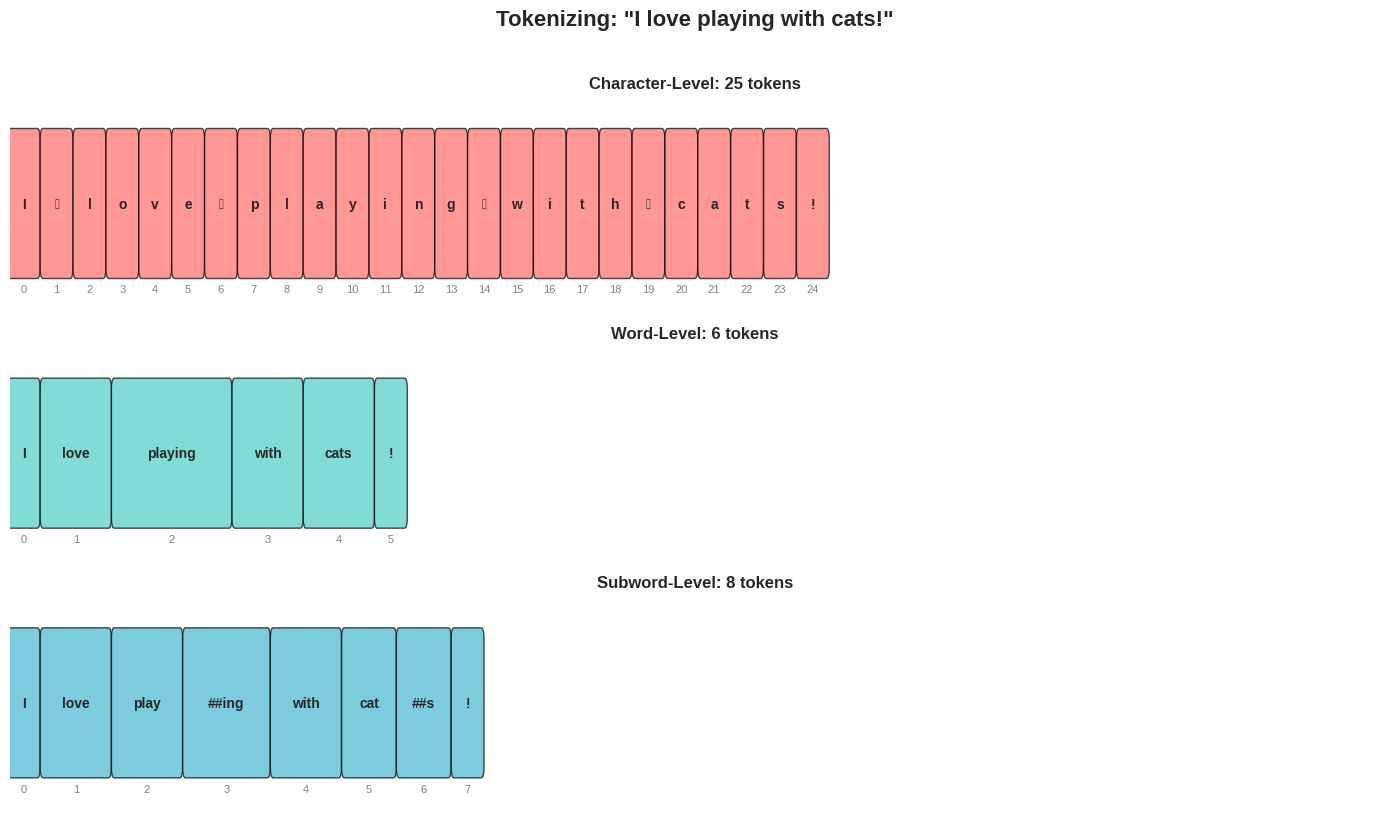

In [ ]:
def visualize_tokenization(text: str):
    """
    Visualize three different tokenization strategies side by side.

    This helps you understand how the same sentence can be
    broken down in different ways!
    """
    # Character-level tokenization
    char_tokens = list(text)

    # Word-level tokenization (simple split on spaces and punctuation)
    import re
    word_tokens = re.findall(r"\w+|[^\w\s]", text)

    # Subword tokenization (simplified BPE-like)
    # For demo, we'll split common suffixes
    subword_tokens = []
    for word in word_tokens:
        if word.endswith('ing'):
            subword_tokens.extend([word[:-3], '##ing'])
        elif word.endswith('ed'):
            subword_tokens.extend([word[:-2], '##ed'])
        elif word.endswith('s') and len(word) > 2:
            subword_tokens.extend([word[:-1], '##s'])
        else:
            subword_tokens.append(word)

    # Create visualization
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    fig.suptitle(f'Tokenizing: "{text}"', fontsize=16, fontweight='bold', y=1.02)

    methods = [
        ('Character-Level', char_tokens, '#FF6B6B'),
        ('Word-Level', word_tokens, '#4ECDC4'),
        ('Subword-Level', subword_tokens, '#45B7D1')
    ]

    for ax, (name, tokens, color) in zip(axes, methods):
        ax.set_xlim(0, max(len(char_tokens), 15))
        ax.set_ylim(0, 1)
        ax.set_title(f'{name}: {len(tokens)} tokens', fontsize=12, fontweight='bold')
        ax.axis('off')

        # Draw tokens as boxes
        x_pos = 0
        for i, token in enumerate(tokens):
            width = max(len(token) * 0.3, 0.5)
            rect = FancyBboxPatch(
                (x_pos, 0.2), width, 0.6,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor='black', alpha=0.7
            )
            ax.add_patch(rect)

            # Add token text
            display_token = token if token != ' ' else '⎵'
            ax.text(x_pos + width/2, 0.5, display_token,
                   ha='center', va='center', fontsize=10, fontweight='bold')
            ax.text(x_pos + width/2, 0.1, str(i),
                   ha='center', va='center', fontsize=8, color='gray')

            x_pos += width + 0.1

    plt.tight_layout()
    plt.show()

    return char_tokens, word_tokens, subword_tokens

# Try it out!
char_tok, word_tok, subword_tok = visualize_tokenization("I love playing with cats!")

### Hands-On Exercise: Tokenization

Let's build a simple tokenizer from scratch!

In [ ]:
class SimpleTokenizer:
    """
    A simple word-level tokenizer built from scratch.

    This is how early NLP systems processed text!
    """

    def __init__(self):
        self.word_to_id = {}   # Maps words to unique numbers
        self.id_to_word = {}   # Maps numbers back to words
        self.vocab_size = 0

        # Special tokens
        self._add_word('[PAD]')   # Padding for equal-length sequences
        self._add_word('[UNK]')   # Unknown words not in vocabulary
        self._add_word('[START]') # Start of sentence
        self._add_word('[END]')   # End of sentence

    def _add_word(self, word: str):
        """Add a word to our vocabulary."""
        if word not in self.word_to_id:
            self.word_to_id[word] = self.vocab_size
            self.id_to_word[self.vocab_size] = word
            self.vocab_size += 1

    def fit(self, texts: List[str]):
        """
        Build vocabulary from a list of texts.

        Args:
            texts: List of sentences to learn vocabulary from
        """
        print("🔨 Building vocabulary...")
        for text in texts:
            words = text.lower().split()
            for word in words:
                # Remove punctuation for simplicity
                word = ''.join(c for c in word if c.isalnum())
                if word:
                    self._add_word(word)
        print(f"✅ Vocabulary built! Size: {self.vocab_size} words")
        return self

    def encode(self, text: str) -> List[int]:
        """
        Convert text to a sequence of numbers.

        Args:
            text: Input sentence

        Returns:
            List of token IDs
        """
        tokens = [self.word_to_id['[START]']]
        words = text.lower().split()
        for word in words:
            word = ''.join(c for c in word if c.isalnum())
            if word:
                token_id = self.word_to_id.get(word, self.word_to_id['[UNK]'])
                tokens.append(token_id)
        tokens.append(self.word_to_id['[END]'])
        return tokens

    def decode(self, token_ids: List[int]) -> str:
        """
        Convert number sequence back to text.

        Args:
            token_ids: List of token IDs

        Returns:
            Decoded text string
        """
        words = [self.id_to_word.get(id, '[UNK]') for id in token_ids]
        # Remove special tokens for cleaner output
        words = [w for w in words if not w.startswith('[')]
        return ' '.join(words)

    def visualize_encoding(self, text: str):
        """Show the encoding process step by step."""
        token_ids = self.encode(text)

        print(f"\n📝 Original: \"{text}\"")
        print("\n" + "="*50)
        print("     WORD       →    ID")
        print("="*50)

        words = ['[START]'] + text.lower().split() + ['[END]']
        for word, token_id in zip(words, token_ids):
            clean_word = ''.join(c for c in word if c.isalnum() or c in '[]')
            print(f"  {clean_word:15} →  {token_id:3}")

        print("="*50)
        print(f"\n📊 Encoded: {token_ids}")
        print(f"🔄 Decoded: \"{self.decode(token_ids)}\"")

# Let's try it!
training_texts = [
    "I love deep learning",
    "Neural networks are amazing",
    "Deep learning is fun",
    "I study artificial intelligence",
    "Transformers changed everything"
]

tokenizer = SimpleTokenizer()
tokenizer.fit(training_texts)

# Test encoding
tokenizer.visualize_encoding("I love neural networks")

🔨 Building vocabulary...
✅ Vocabulary built! Size: 20 words

📝 Original: "I love neural networks"

     WORD       →    ID
  [START]         →    2
  i               →    4
  love            →    5
  neural          →    8
  networks        →    9
  [END]           →    3

📊 Encoded: [2, 4, 5, 8, 9, 3]
🔄 Decoded: "i love neural networks"


### Key Insight: The Vocabulary Trade-off

```
                    TOKENIZATION TRADE-OFFS
                    
    Small Vocabulary                      Large Vocabulary
    (Characters)                          (Words)
          │                                     │
          ▼                                     ▼
    ┌─────────────┐                       ┌─────────────┐
    │ • Long      │                       │ • Short     │
    │   sequences │                       │   sequences │
    │ • Universal │                       │ • Many OOV  │
    │ • Slow      │                       │ • Fast      │
    └─────────────┘                       └─────────────┘
                         │
                         ▼
                  ┌─────────────┐
                  │  SUBWORD    │  ← Modern Solution!
                  │ (BPE, etc.) │
                  │ Best of     │
                  │ both worlds │
                  └─────────────┘
```

Modern models like GPT and BERT use **subword tokenization** (BPE, WordPiece) which:
- Handles rare words by breaking them into pieces
- Keeps common words as single tokens
- Balances vocabulary size with sequence length

---

## 1.2 Word Embeddings: Giving Words Meaning

### The Problem: Words Are Just Symbols

So far, we've converted words to numbers (token IDs). But there's a problem:

```
"cat" → 42      "dog" → 87      "kitten" → 156
```

These numbers are **arbitrary**! The model doesn't know that "cat" and "kitten" are related, or that "cat" is more similar to "dog" than to "airplane."

### The Solution: Word Embeddings

**Word embeddings** are dense, low-dimensional vectors that capture the **semantic and syntactic structure** of words. Similar words have embeddings that are **close to each other** in vector space!

```
                           WORD EMBEDDING SPACE

                              (furry, pet)
                                   ↑
                           🐱 cat  ●────────● dog 🐕
                                   │
                                   │ (small, young)
                           kitten ●

        ←───────────────────────────────────────────────→

                                   │
                                   │
                        airplane ● │
                                   │ (machine, fly)
                                   ↓
```

### The Magic: Relationships Are Preserved!

Famous example: **King - Man + Woman ≈ Queen**

```
      king           man          woman         queen
    [0.8, 0.3]  -  [0.7, 0.1]  +  [0.2, 0.9]  ≈  [0.3, 1.1]
         │              │              │              │
         └──────────────┴──────────────┴──────────────┘
                    Vector Arithmetic!
```

In [ ]:
class WordEmbeddings:
    """
    A simple word embedding system to understand how embeddings work.

    In practice, embeddings are learned during training, but we'll
    create some manually to visualize the concept!
    """

    def __init__(self, embedding_dim: int = 50):
        """
        Initialize the embedding system.

        Args:
            embedding_dim: Size of each embedding vector (how many numbers per word)
        """
        self.embedding_dim = embedding_dim
        self.word_to_embedding = {}

    def add_word(self, word: str, embedding: np.ndarray = None):
        """Add a word with its embedding (random if not provided)."""
        if embedding is None:
            embedding = np.random.randn(self.embedding_dim) * 0.1
        self.word_to_embedding[word.lower()] = np.array(embedding)

    def get_embedding(self, word: str) -> np.ndarray:
        """Get the embedding for a word."""
        return self.word_to_embedding.get(word.lower(), np.zeros(self.embedding_dim))

    def similarity(self, word1: str, word2: str) -> float:
        """
        Calculate cosine similarity between two words.

        Cosine similarity measures the angle between vectors:
        - 1.0 = identical direction (very similar)
        - 0.0 = perpendicular (unrelated)
        - -1.0 = opposite direction (antonyms)
        """
        e1 = self.get_embedding(word1)
        e2 = self.get_embedding(word2)

        # Cosine similarity formula: (A · B) / (||A|| × ||B||)
        dot_product = np.dot(e1, e2)
        norm1 = np.linalg.norm(e1)
        norm2 = np.linalg.norm(e2)

        if norm1 == 0 or norm2 == 0:
            return 0.0
        return dot_product / (norm1 * norm2)

# Create embeddings with meaningful patterns
embeddings = WordEmbeddings(embedding_dim=4)

# Let's create embeddings where similar words are close
# Format: [royalty, gender_male, age, power]

# Royalty dimension
embeddings.add_word("king",   np.array([0.9, 0.8, 0.7, 0.9]))
embeddings.add_word("queen",  np.array([0.9, 0.2, 0.7, 0.8]))
embeddings.add_word("prince", np.array([0.8, 0.8, 0.3, 0.5]))
embeddings.add_word("princess", np.array([0.8, 0.2, 0.3, 0.4]))

# Common people
embeddings.add_word("man",    np.array([0.1, 0.9, 0.6, 0.3]))
embeddings.add_word("woman",  np.array([0.1, 0.1, 0.6, 0.3]))
embeddings.add_word("boy",    np.array([0.1, 0.8, 0.2, 0.1]))
embeddings.add_word("girl",   np.array([0.1, 0.2, 0.2, 0.1]))

# Animals
embeddings.add_word("cat",    np.array([-0.5, 0.3, 0.4, -0.2]))
embeddings.add_word("dog",    np.array([-0.4, 0.4, 0.5, -0.1]))
embeddings.add_word("kitten", np.array([-0.5, 0.2, 0.1, -0.3]))
embeddings.add_word("puppy",  np.array([-0.4, 0.3, 0.1, -0.2]))

print("✅ Word embeddings created!")
print("\n📊 Sample embedding for 'king':", embeddings.get_embedding("king"))

✅ Word embeddings created!

📊 Sample embedding for 'king': [0.9 0.8 0.7 0.9]


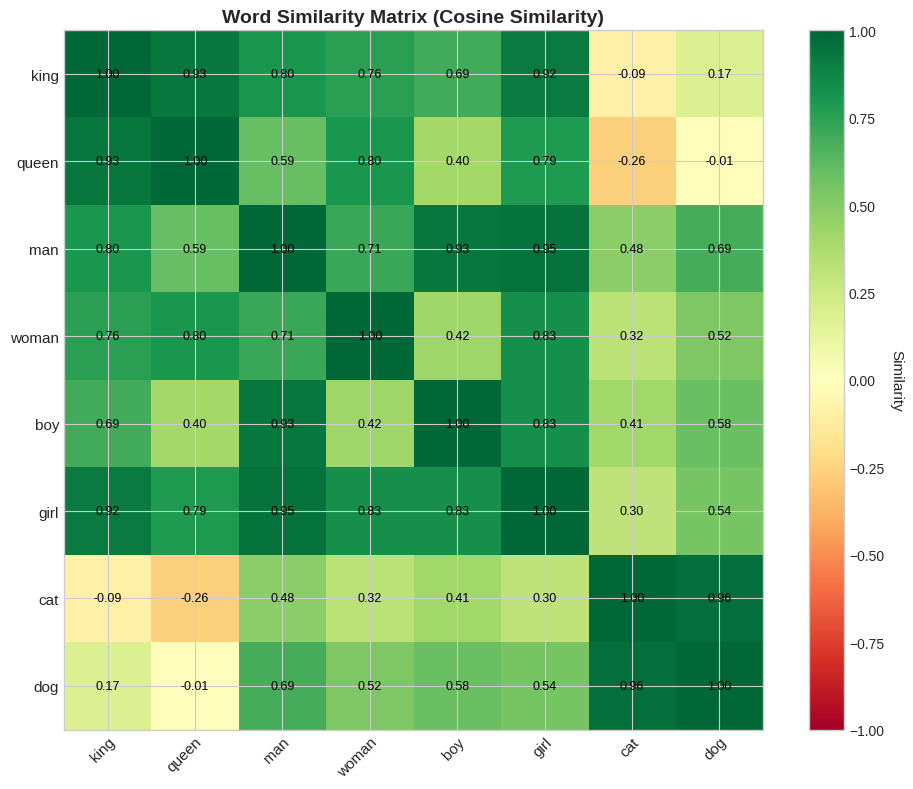

In [ ]:
# Let's visualize word similarities!

def visualize_word_similarities(embeddings, words: List[str]):
    """Create a heatmap showing how similar words are to each other."""

    n = len(words)
    similarity_matrix = np.zeros((n, n))

    for i, word1 in enumerate(words):
        for j, word2 in enumerate(words):
            similarity_matrix[i, j] = embeddings.similarity(word1, word2)

    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=-1, vmax=1)

    # Add labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(words, fontsize=11)
    ax.set_yticklabels(words, fontsize=11)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add values in cells
    for i in range(n):
        for j in range(n):
            text = ax.text(j, i, f"{similarity_matrix[i, j]:.2f}",
                          ha="center", va="center", color="black", fontsize=9)

    ax.set_title("Word Similarity Matrix (Cosine Similarity)", fontsize=14, fontweight='bold')

    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Similarity", rotation=-90, va="bottom", fontsize=11)

    plt.tight_layout()
    plt.show()

    return similarity_matrix

# Visualize!
words_to_compare = ["king", "queen", "man", "woman", "boy", "girl", "cat", "dog"]
sim_matrix = visualize_word_similarities(embeddings, words_to_compare)

### 🧪 Hands-On: The Famous Analogy Test

Let's verify the famous relationship: **King - Man + Woman ≈ Queen**

In [ ]:
def word_analogy(embeddings, word_a: str, word_b: str, word_c: str):
    """
    Solve word analogies: A is to B as C is to ?

    Example: King is to Man as Queen is to Woman
    Formula: embedding(A) - embedding(B) + embedding(C) ≈ embedding(?)
    """
    # Get embeddings
    vec_a = embeddings.get_embedding(word_a)
    vec_b = embeddings.get_embedding(word_b)
    vec_c = embeddings.get_embedding(word_c)

    # Calculate: A - B + C
    result_vec = vec_a - vec_b + vec_c

    # Find most similar word
    best_word = None
    best_similarity = -2

    for word in embeddings.word_to_embedding.keys():
        if word in [word_a, word_b, word_c]:
            continue

        vec = embeddings.get_embedding(word)
        # Cosine similarity
        similarity = np.dot(result_vec, vec) / (np.linalg.norm(result_vec) * np.linalg.norm(vec) + 1e-8)

        if similarity > best_similarity:
            best_similarity = similarity
            best_word = word

    return best_word, best_similarity

def visualize_analogy(embeddings, word_a, word_b, word_c):
    """Visualize the analogy computation step by step."""

    result_word, similarity = word_analogy(embeddings, word_a, word_b, word_c)

    print("╔════════════════════════════════════════════════════════════╗")
    print("║                   WORD ANALOGY SOLVER                       ║")
    print("╠════════════════════════════════════════════════════════════╣")
    print(f"║  {word_a.upper()} is to {word_b.upper()} as {word_c.upper()} is to ???")
    print("╠════════════════════════════════════════════════════════════╣")
    print("║                                                            ║")
    print(f"║  Step 1: Get embedding({word_a})")
    print(f"║          → {embeddings.get_embedding(word_a)}")
    print("║                                                            ║")
    print(f"║  Step 2: Subtract embedding({word_b})")
    print(f"║          → {embeddings.get_embedding(word_b)}")
    print("║                                                            ║")
    print(f"║  Step 3: Add embedding({word_c})")
    print(f"║          → {embeddings.get_embedding(word_c)}")
    print("║                                                            ║")
    print("╠════════════════════════════════════════════════════════════╣")
    print(f"║  🎯 ANSWER: {result_word.upper()}  (similarity: {similarity:.3f})")
    print("╚════════════════════════════════════════════════════════════╝")

    return result_word

# Test the famous analogy!
print("🧪 Testing: King - Man + Woman = ?\n")
result = visualize_analogy(embeddings, "king", "man", "woman")

print("\n" + "="*60)
print("\n🧪 Testing: Prince - Boy + Girl = ?\n")
result = visualize_analogy(embeddings, "prince", "boy", "girl")

🧪 Testing: King - Man + Woman = ?

╔════════════════════════════════════════════════════════════╗
║                   WORD ANALOGY SOLVER                       ║
╠════════════════════════════════════════════════════════════╣
║  KING is to MAN as WOMAN is to ???
╠════════════════════════════════════════════════════════════╣
║                                                            ║
║  Step 1: Get embedding(king)
║          → [0.9 0.8 0.7 0.9]
║                                                            ║
║  Step 2: Subtract embedding(man)
║          → [0.1 0.9 0.6 0.3]
║                                                            ║
║  Step 3: Add embedding(woman)
║          → [0.1 0.1 0.6 0.3]
║                                                            ║
╠════════════════════════════════════════════════════════════╣
║  🎯 ANSWER: QUEEN  (similarity: 0.988)
╚════════════════════════════════════════════════════════════╝


🧪 Testing: Prince - Boy + Girl = ?

╔═══════════════════════════

### 2D Visualization of Word Embeddings

Let's project our embeddings to 2D to see how words cluster!

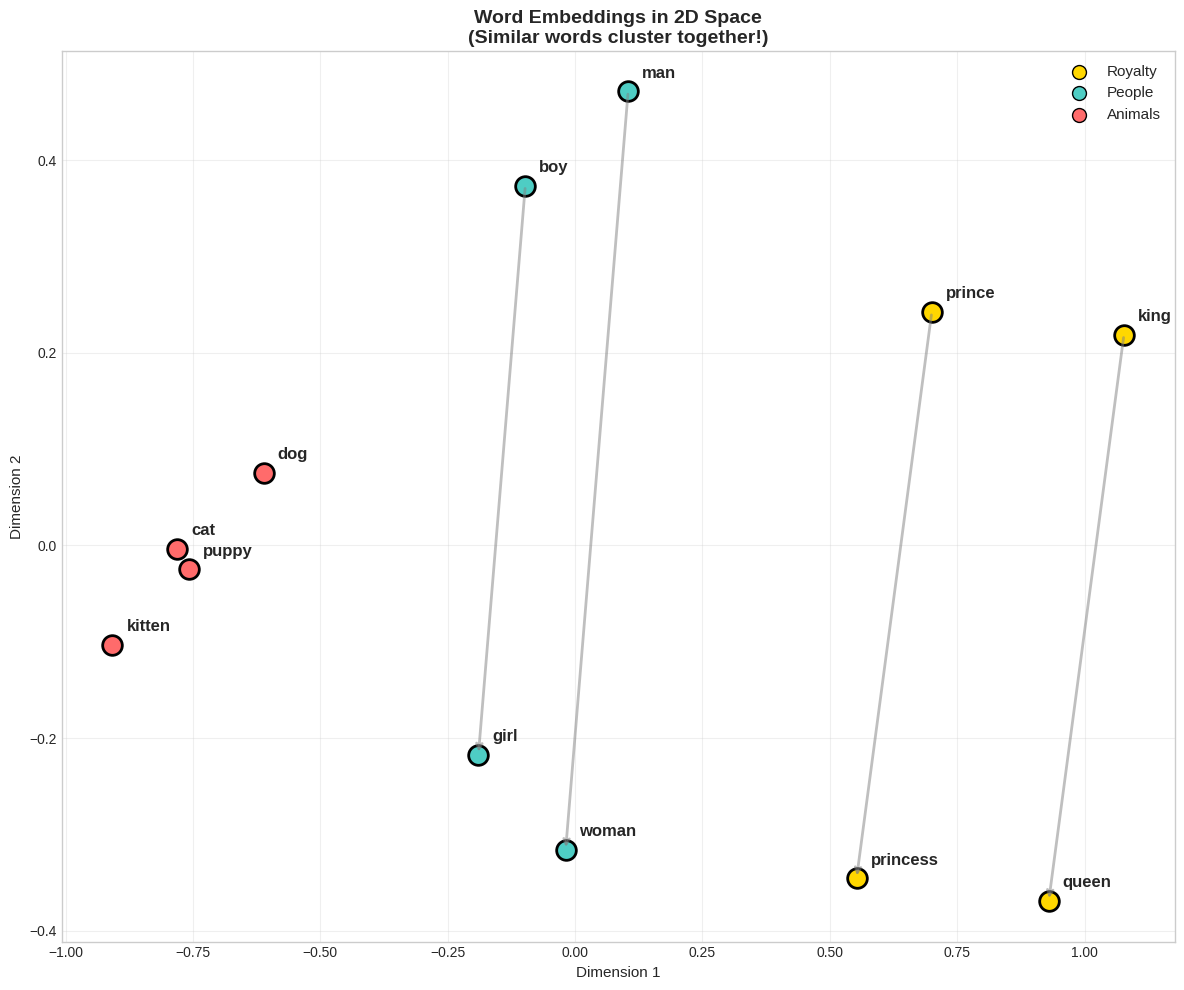

In [ ]:
def visualize_embeddings_2d(embeddings, words: List[str]):
    """
    Project high-dimensional embeddings to 2D for visualization.
    Uses PCA (Principal Component Analysis) for dimensionality reduction.
    """
    from sklearn.decomposition import PCA

    # Get all embeddings
    vectors = np.array([embeddings.get_embedding(w) for w in words])

    # Reduce to 2D
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 10))

    # Define color groups
    colors = {
        'royalty': '#FFD700',      # Gold for royalty
        'people': '#4ECDC4',       # Teal for common people
        'animals': '#FF6B6B'       # Coral for animals
    }

    groups = {
        'royalty': ['king', 'queen', 'prince', 'princess'],
        'people': ['man', 'woman', 'boy', 'girl'],
        'animals': ['cat', 'dog', 'kitten', 'puppy']
    }

    # Plot each word
    for i, word in enumerate(words):
        # Determine color
        for group, group_words in groups.items():
            if word in group_words:
                color = colors[group]
                break
        else:
            color = 'gray'

        ax.scatter(vectors_2d[i, 0], vectors_2d[i, 1],
                  c=color, s=200, edgecolors='black', linewidth=2, zorder=2)
        ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                   fontsize=12, fontweight='bold',
                   xytext=(10, 10), textcoords='offset points')

    # Add legend
    legend_elements = [
        plt.scatter([], [], c=colors['royalty'], s=100, label='Royalty', edgecolors='black'),
        plt.scatter([], [], c=colors['people'], s=100, label='People', edgecolors='black'),
        plt.scatter([], [], c=colors['animals'], s=100, label='Animals', edgecolors='black'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

    # Draw connections for analogies
    # King to Queen, Man to Woman
    for (w1, w2) in [('king', 'queen'), ('man', 'woman'), ('prince', 'princess'), ('boy', 'girl')]:
        if w1 in words and w2 in words:
            idx1, idx2 = words.index(w1), words.index(w2)
            ax.annotate('', xy=vectors_2d[idx2], xytext=vectors_2d[idx1],
                       arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=2))

    ax.set_title('Word Embeddings in 2D Space\n(Similar words cluster together!)',
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Dimension 1', fontsize=11)
    ax.set_ylabel('Dimension 2', fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize all our words
all_words = ["king", "queen", "prince", "princess", "man", "woman", "boy", "girl",
             "cat", "dog", "kitten", "puppy"]
visualize_embeddings_2d(embeddings, all_words)

### Key Takeaways: Word Embeddings

```
╔══════════════════════════════════════════════════════════════════╗
║                    WORD EMBEDDINGS SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. WHAT: Dense vectors representing words (50-300 dimensions)   ║
║                                                                   ║
║  2. WHY: Capture semantic meaning - similar words = similar      ║
║          vectors                                                  ║
║                                                                   ║
║  3. HOW: Learned from large text corpora (Word2Vec, GloVe)       ║
║          or as part of larger models (BERT, GPT)                 ║
║                                                                   ║
║  4. MAGIC: Vector arithmetic preserves relationships!            ║
║            King - Man + Woman ≈ Queen                            ║
║                                                                   ║
║  5. FOUNDATION: Every modern NLP model uses embeddings           ║
║                 as its first layer!                              ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
```

**Coming up next:** Now that we can represent words as vectors, how do we process **sequences** of words? Enter: Recurrent Neural Networks!

---

# Chapter 2: Sequential Models - RNNs, LSTMs & Attention

## 2.1 Recurrent Neural Networks (RNNs)

### The Problem: Order Matters in Language!

Consider these two sentences:
- "The dog chased the cat" vs "The cat chased the dog"

Same words, completely different meanings! We need a model that **preserves the order of tokens** in a sequence.

### The Solution: Recurrent Neural Networks

An RNN is a neural network that maintains a **hidden state** that gets updated as it reads each word. Think of it as the network's "memory" of what it has seen so far.

```
                         RNN: READING A SENTENCE
                         
    "I"        "love"       "deep"     "learning"
     │           │            │            │
     ▼           ▼            ▼            ▼
  ┌──────┐   ┌──────┐    ┌──────┐    ┌──────┐
  │ RNN  │──▶│ RNN  │───▶│ RNN  │───▶│ RNN  │
  │ Cell │   │ Cell │    │ Cell │    │ Cell │
  └──────┘   └──────┘    └──────┘    └──────┘
     │           │            │            │
     ▼           ▼            ▼            ▼
    h₀          h₁           h₂           h₃
  (start)   ("I...")    ("I love..") ("I love deep..")
  
  The hidden state h carries information about ALL previous words!
```

### How Does an RNN Cell Work?

At each time step t, the RNN cell:
1. Takes the current word embedding (iₜ)
2. Combines it with the previous hidden state (hₜ₋₁)
3. Produces a new hidden state (hₜ) and output (oₜ)

**The Math (Simple Version):**
```
hₜ = tanh(W_h · hₜ₋₁ + W_i · iₜ + b)
oₜ = W_o · hₜ
```

Where:
- `W_h`, `W_i`, `W_o` are learnable weight matrices
- `tanh` squashes values between -1 and 1
- `b` is a bias term

🔄 Processing sequence through RNN...
Step 1: Reading 'I' with embedding [ 0.5  0.2 -0.3  0.8]
Step 2: Reading 'love' with embedding [ 0.9 -0.1  0.4  0.2]
Step 3: Reading 'deep' with embedding [-0.2  0.7  0.6 -0.4]
Step 4: Reading 'learning' with embedding [ 0.3  0.5 -0.1  0.9]

✅ Final hidden state captures the entire sequence!
   Shape: (6, 1)


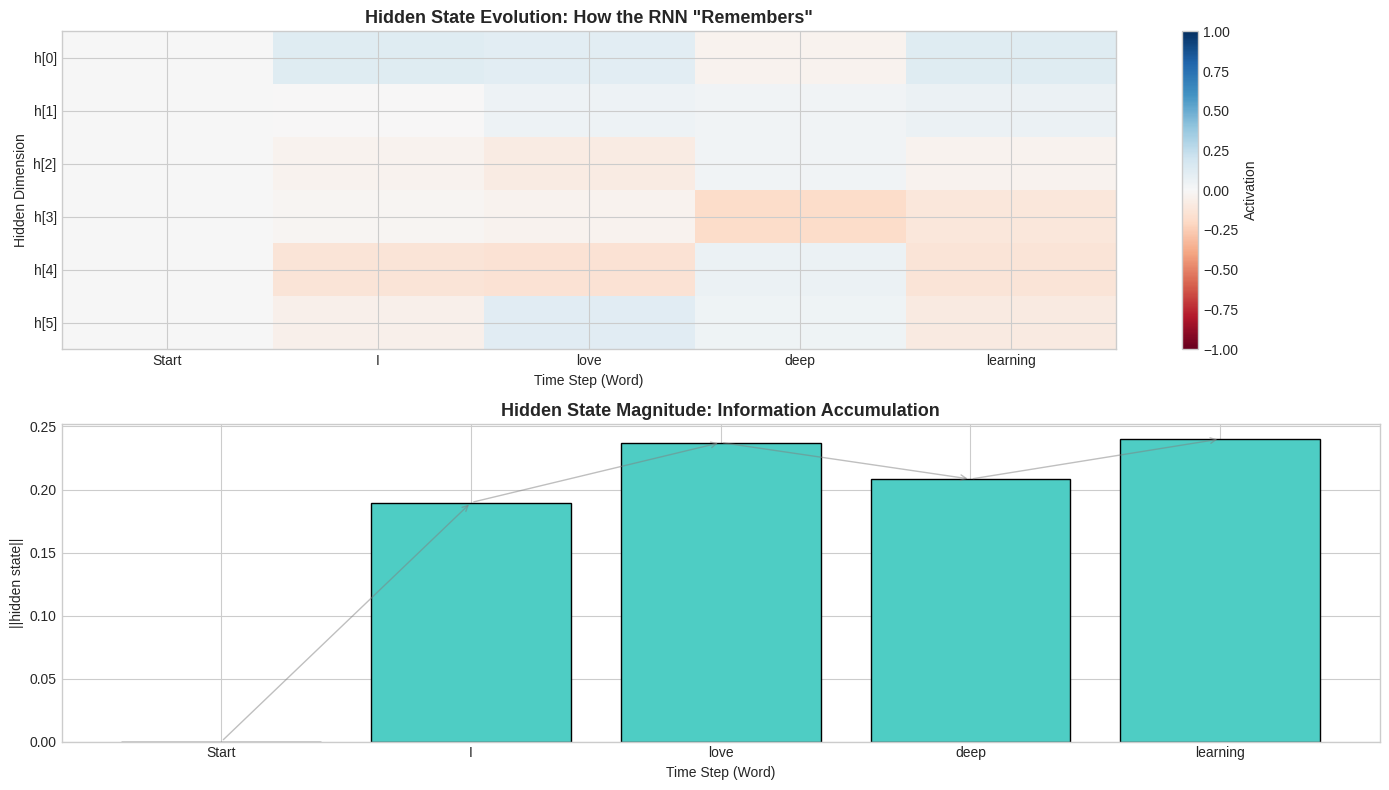

In [ ]:
class SimpleRNN:
    """
    A simple RNN implementation from scratch to understand the mechanics.

    This is the basic RNN cell that processes sequences one token at a time,
    maintaining a hidden state that carries information through the sequence.
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        """
        Initialize the RNN with random weights.

        Args:
            input_dim: Size of input embeddings
            hidden_dim: Size of hidden state (the "memory")
            output_dim: Size of output at each step
        """
        self.hidden_dim = hidden_dim

        # Initialize weights with small random values
        scale = 0.1
        self.W_i = np.random.randn(hidden_dim, input_dim) * scale   # Input weights
        self.W_h = np.random.randn(hidden_dim, hidden_dim) * scale  # Hidden weights
        self.W_o = np.random.randn(output_dim, hidden_dim) * scale  # Output weights
        self.b_h = np.zeros((hidden_dim, 1))                        # Hidden bias
        self.b_o = np.zeros((output_dim, 1))                        # Output bias

        # Store states for visualization
        self.hidden_states = []
        self.outputs = []

    def forward(self, inputs: List[np.ndarray], visualize: bool = True) -> np.ndarray:
        """
        Process a sequence of inputs through the RNN.

        Args:
            inputs: List of input embeddings (one per time step)
            visualize: Whether to store states for visualization

        Returns:
            Final hidden state (summary of entire sequence)
        """
        # Initialize hidden state to zeros
        h = np.zeros((self.hidden_dim, 1))

        self.hidden_states = [h.copy()]
        self.outputs = []

        # Process each input in sequence
        for t, x in enumerate(inputs):
            # Reshape input to column vector if needed
            x = x.reshape(-1, 1)

            # RNN cell computation:
            # h_new = tanh(W_i · x + W_h · h + b_h)
            h_new = np.tanh(self.W_i @ x + self.W_h @ h + self.b_h)

            # Output at this step
            o = self.W_o @ h_new + self.b_o

            # Update hidden state
            h = h_new

            # Store for visualization
            self.hidden_states.append(h.copy())
            self.outputs.append(o.copy())

        return h  # Return final hidden state

    def visualize_processing(self, words: List[str]):
        """
        Create a beautiful visualization of how the RNN processes a sequence.
        """
        n_steps = len(words)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8))

        # Top plot: Hidden state evolution
        ax1 = axes[0]
        hidden_matrix = np.hstack(self.hidden_states).T  # (n_steps+1, hidden_dim)

        im1 = ax1.imshow(hidden_matrix.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
        ax1.set_yticks(range(self.hidden_dim))
        ax1.set_yticklabels([f'h[{i}]' for i in range(self.hidden_dim)])
        ax1.set_xticks(range(n_steps + 1))
        ax1.set_xticklabels(['Start'] + words)
        ax1.set_title('Hidden State Evolution: How the RNN "Remembers"', fontsize=13, fontweight='bold')
        ax1.set_xlabel('Time Step (Word)')
        ax1.set_ylabel('Hidden Dimension')
        plt.colorbar(im1, ax=ax1, label='Activation')

        # Bottom plot: Hidden state magnitude over time
        ax2 = axes[1]
        magnitudes = [np.linalg.norm(h) for h in self.hidden_states]

        ax2.bar(range(n_steps + 1), magnitudes, color='#4ECDC4', edgecolor='black')
        ax2.set_xticks(range(n_steps + 1))
        ax2.set_xticklabels(['Start'] + words)
        ax2.set_title('Hidden State Magnitude: Information Accumulation', fontsize=13, fontweight='bold')
        ax2.set_xlabel('Time Step (Word)')
        ax2.set_ylabel('||hidden state||')

        # Add arrows showing information flow
        for i in range(n_steps):
            ax2.annotate('', xy=(i+1, magnitudes[i+1]), xytext=(i, magnitudes[i]),
                        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

        plt.tight_layout()
        plt.show()

# Create a simple RNN
rnn = SimpleRNN(input_dim=4, hidden_dim=6, output_dim=4)

# Create some sample word embeddings
sample_words = ["I", "love", "deep", "learning"]
sample_embeddings = [
    np.array([0.5, 0.2, -0.3, 0.8]),
    np.array([0.9, -0.1, 0.4, 0.2]),
    np.array([-0.2, 0.7, 0.6, -0.4]),
    np.array([0.3, 0.5, -0.1, 0.9])
]

# Process the sequence
print("🔄 Processing sequence through RNN...")
print("=" * 50)
for i, (word, emb) in enumerate(zip(sample_words, sample_embeddings)):
    print(f"Step {i+1}: Reading '{word}' with embedding {emb}")

final_state = rnn.forward(sample_embeddings)
print("=" * 50)
print(f"\n✅ Final hidden state captures the entire sequence!")
print(f"   Shape: {final_state.shape}")

# Visualize!
rnn.visualize_processing(sample_words)

### Bidirectional RNNs: Reading Both Ways

Sometimes we need context from **both directions**. Consider:

> "The bank by the river was beautiful" vs "I deposited money in the bank"

The meaning of "bank" depends on words that come **after** it!

**Bidirectional RNNs** solve this by running two RNNs:
1. **Forward RNN**: Reads left → right
2. **Backward RNN**: Reads right → left

```
                    BIDIRECTIONAL RNN
                    
    "I"      "love"     "the"      "bank"
     │         │          │          │
     ▼         ▼          ▼          ▼
  ┌─────┐  ┌─────┐    ┌─────┐    ┌─────┐
  │ → → │──│ → → │────│ → → │────│ → → │  Forward
  └─────┘  └─────┘    └─────┘    └─────┘
     │         │          │          │
     │    ┌────┴────┐┌────┴────┐┌────┴────┐
     │    │ CONCAT  ││ CONCAT  ││ CONCAT  │
     │    └────┬────┘└────┬────┘└────┬────┘
     │         │          │          │
  ┌─────┐  ┌─────┐    ┌─────┐    ┌─────┐
  │ ← ← │──│ ← ← │────│ ← ← │────│ ← ← │  Backward
  └─────┘  └─────┘    └─────┘    └─────┘
     ▲         ▲          ▲          ▲
    "I"      "love"     "the"      "bank"
    
  Final embedding for each word = [forward_h ; backward_h]
```

---

## 2.2 LSTMs and GRUs: Remembering Longer!

### The Vanishing Gradient Problem

Basic RNNs have a serious issue: **they forget!**

When processing long sequences, information from early words gets "washed out" as we go through many time steps. This is because gradients become tiny during backpropagation (vanishing gradients).

```
            THE VANISHING GRADIENT PROBLEM
            
    Word 1    Word 2    Word 3    Word 4   ...   Word 100
      │         │         │         │              │
      ▼         ▼         ▼         ▼              ▼
    ┌───┐     ┌───┐     ┌───┐     ┌───┐         ┌───┐
    │RNN│────▶│RNN│────▶│RNN│────▶│RNN│──...───▶│RNN│
    └───┘     └───┘     └───┘     └───┘         └───┘
      │         │         │         │              │
      │◀────────│◀────────│◀────────│◀─── ... ◀───│
      │                                            │
      │    Gradients get multiplied at each step   │
      │    0.9 × 0.9 × 0.9 × ... = nearly 0!       │
      │                                            │
    Word 1's influence on Word 100 prediction = 😢
```

### The Solution: Gates!

**LSTM** (Long Short-Term Memory) and **GRU** (Gated Recurrent Unit) add special **gates** that control information flow:

```
                    LSTM GATES VISUALIZATION
                    
    ┌─────────────────────────────────────────────────────┐
    │                     LSTM CELL                        │
    │                                                      │
    │   🚪 FORGET GATE     🚪 INPUT GATE     🚪 OUTPUT GATE │
    │   "What to forget"   "What to add"     "What to output"│
    │         │                 │                  │        │
    │         ▼                 ▼                  ▼        │
    │    ┌─────────┐      ┌─────────┐        ┌─────────┐   │
    │    │ σ(...)  │      │ σ(...)  │        │ σ(...)  │   │
    │    └────┬────┘      └────┬────┘        └────┬────┘   │
    │         │                 │                  │        │
    │         ▼                 ▼                  ▼        │
    │    ×─────────────────────────────────────────×       │
    │              CELL STATE (Long-term memory)           │
    │                         ═══════                      │
    └─────────────────────────────────────────────────────┘
    
    σ = sigmoid function (outputs 0 to 1, like a "gate")
    × = element-wise multiplication
```

### Think of It Like This:

| Gate | Question It Answers | Example |
|------|-------------------|---------|
| **Forget** | Should I forget this old info? | Forget "she" when we see "he" |
| **Input** | Should I remember this new info? | Remember important keywords |
| **Output** | What should I output right now? | Output relevant info for next word |

🧠 Processing through LSTM...
✅ LSTM processed 4 words
   Hidden state shape: (8, 1)
   Cell state shape: (8, 1)


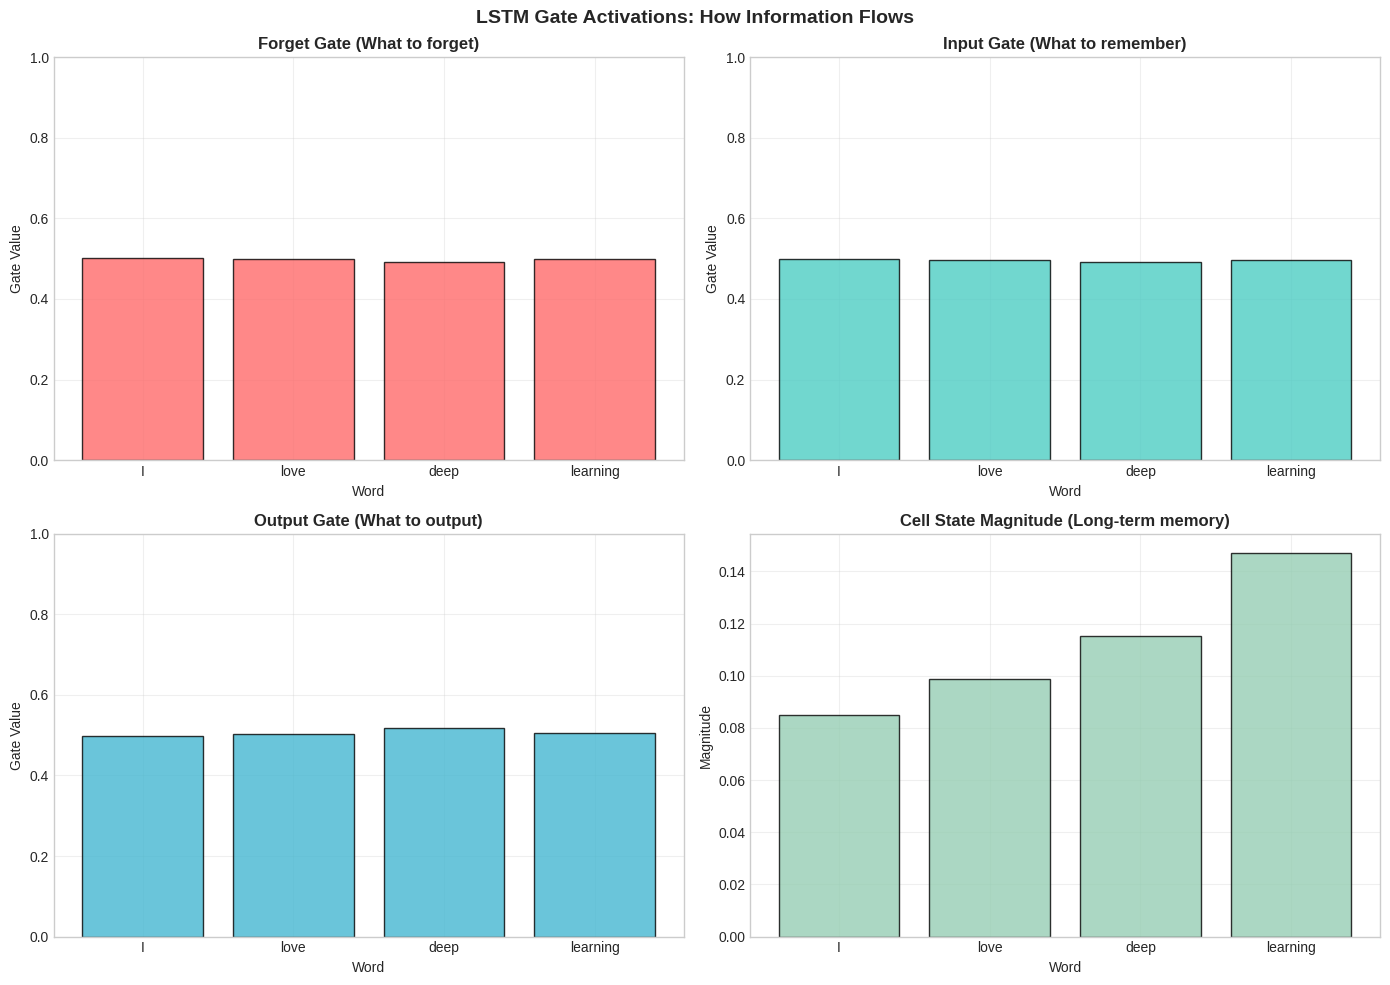

In [ ]:
class SimpleLSTM:
    """
    A simplified LSTM implementation to understand the gate mechanisms.

    LSTM adds 3 gates to control information flow:
    - Forget gate: What to forget from cell state
    - Input gate: What new info to add
    - Output gate: What to output from cell state
    """

    def __init__(self, input_dim: int, hidden_dim: int):
        self.hidden_dim = hidden_dim

        # Initialize weights for all gates
        scale = 0.1

        # Forget gate weights
        self.W_f = np.random.randn(hidden_dim, input_dim + hidden_dim) * scale
        self.b_f = np.zeros((hidden_dim, 1))

        # Input gate weights
        self.W_i = np.random.randn(hidden_dim, input_dim + hidden_dim) * scale
        self.b_i = np.zeros((hidden_dim, 1))

        # Cell candidate weights
        self.W_c = np.random.randn(hidden_dim, input_dim + hidden_dim) * scale
        self.b_c = np.zeros((hidden_dim, 1))

        # Output gate weights
        self.W_o = np.random.randn(hidden_dim, input_dim + hidden_dim) * scale
        self.b_o = np.zeros((hidden_dim, 1))

        # Storage for visualization
        self.gate_history = {'forget': [], 'input': [], 'output': [], 'cell': []}

    def sigmoid(self, x):
        """Sigmoid activation (0 to 1) - perfect for gates!"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def forward(self, inputs: List[np.ndarray]):
        """Process sequence through LSTM."""
        h = np.zeros((self.hidden_dim, 1))  # Hidden state
        c = np.zeros((self.hidden_dim, 1))  # Cell state (long-term memory!)

        self.gate_history = {'forget': [], 'input': [], 'output': [], 'cell': []}

        for x in inputs:
            x = x.reshape(-1, 1)

            # Concatenate input and previous hidden state
            combined = np.vstack([x, h])

            # === FORGET GATE ===
            # "What should we forget from the cell state?"
            f = self.sigmoid(self.W_f @ combined + self.b_f)

            # === INPUT GATE ===
            # "What new information should we store?"
            i = self.sigmoid(self.W_i @ combined + self.b_i)

            # Candidate cell state (what we might add)
            c_tilde = np.tanh(self.W_c @ combined + self.b_c)

            # === UPDATE CELL STATE ===
            # c_new = (forget × c_old) + (input × candidate)
            c = f * c + i * c_tilde

            # === OUTPUT GATE ===
            # "What should we output based on cell state?"
            o = self.sigmoid(self.W_o @ combined + self.b_o)

            # New hidden state
            h = o * np.tanh(c)

            # Store for visualization
            self.gate_history['forget'].append(f.mean())
            self.gate_history['input'].append(i.mean())
            self.gate_history['output'].append(o.mean())
            self.gate_history['cell'].append(np.linalg.norm(c))

        return h, c

    def visualize_gates(self, words: List[str]):
        """Visualize how gates activate for each word."""
        n_steps = len(words)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        colors = {'forget': '#FF6B6B', 'input': '#4ECDC4', 'output': '#45B7D1', 'cell': '#96CEB4'}
        titles = {
            'forget': 'Forget Gate (What to forget)',
            'input': 'Input Gate (What to remember)',
            'output': 'Output Gate (What to output)',
            'cell': 'Cell State Magnitude (Long-term memory)'
        }

        for ax, (gate_name, values) in zip(axes.flat, self.gate_history.items()):
            ax.bar(range(n_steps), values, color=colors[gate_name], edgecolor='black', alpha=0.8)
            ax.set_xticks(range(n_steps))
            ax.set_xticklabels(words, fontsize=10)
            ax.set_title(titles[gate_name], fontsize=12, fontweight='bold')
            ax.set_xlabel('Word')
            ax.set_ylabel('Gate Value' if gate_name != 'cell' else 'Magnitude')
            if gate_name != 'cell':
                ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)

        fig.suptitle('LSTM Gate Activations: How Information Flows', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Create and test LSTM
lstm = SimpleLSTM(input_dim=4, hidden_dim=8)

# Process the same sequence
print("🧠 Processing through LSTM...")
h_final, c_final = lstm.forward(sample_embeddings)
print(f"✅ LSTM processed {len(sample_words)} words")
print(f"   Hidden state shape: {h_final.shape}")
print(f"   Cell state shape: {c_final.shape}")

# Visualize gate activations
lstm.visualize_gates(sample_words)

### LSTM vs GRU: A Quick Comparison

GRU (Gated Recurrent Unit) is a simpler variant with only 2 gates:

```
╔════════════════════════════════════════════════════════════════════╗
║                    LSTM vs GRU COMPARISON                           ║
╠════════════════════════════════════════════════════════════════════╣
║                                                                     ║
║   LSTM (3 gates)                    GRU (2 gates)                  ║
║   ─────────────                     ─────────────                  ║
║   • Forget gate                     • Reset gate                   ║
║   • Input gate                      • Update gate                  ║
║   • Output gate                                                    ║
║   • Cell state                      • No separate cell state       ║
║                                                                     ║
║   ✅ Better for very long           ✅ Faster to train              ║
║      sequences                      ✅ Fewer parameters             ║
║   ✅ More expressive                ✅ Often similar performance    ║
║                                                                     ║
║   Both solve vanishing gradients and work much better than RNNs!   ║
║                                                                     ║
╚════════════════════════════════════════════════════════════════════╝
```

---

## 2.3 Encoder-Decoder: Sequence-to-Sequence (Seq2Seq)

### The Challenge: Transforming One Sequence Into Another

Many NLP tasks require converting one sequence into a different sequence:

| Task | Input | Output |
|------|-------|--------|
| **Translation** | "Je t'aime" (French) | "I love you" (English) |
| **Summarization** | Long article | Short summary |
| **Question Answering** | Question | Answer |

The input and output can have **different lengths**! How do we handle this?

### The Solution: Encoder-Decoder Architecture (2014)

```
                    ENCODER-DECODER ARCHITECTURE
                    
    INPUT SEQUENCE                        OUTPUT SEQUENCE
    "Je"   "t'"   "aime"                  "I"   "love"   "you"
     │      │       │                      ▲      ▲        ▲
     ▼      ▼       ▼                      │      │        │
   ┌────┐ ┌────┐ ┌────┐              ┌────┐ ┌────┐ ┌────┐
   │LSTM│─│LSTM│─│LSTM│─────────────▶│LSTM│─│LSTM│─│LSTM│
   └────┘ └────┘ └────┘    Context   └────┘ └────┘ └────┘
                            Vector         │      │        │
   ◄─── ENCODER ───►                      ▼      ▼        ▼
                                         "I"   "love"   "you"
                           ◄─────── DECODER ───────►
   
   The encoder compresses the input into a single "context vector"
   The decoder generates the output from this context vector
```

### How It Works Step by Step:

1. **Encoder** reads input sequence word by word
2. Final hidden state becomes the **context vector** (summary of input)
3. **Decoder** receives context vector as initial state
4. Decoder generates output one word at a time
5. Each generated word is fed back as input for the next step

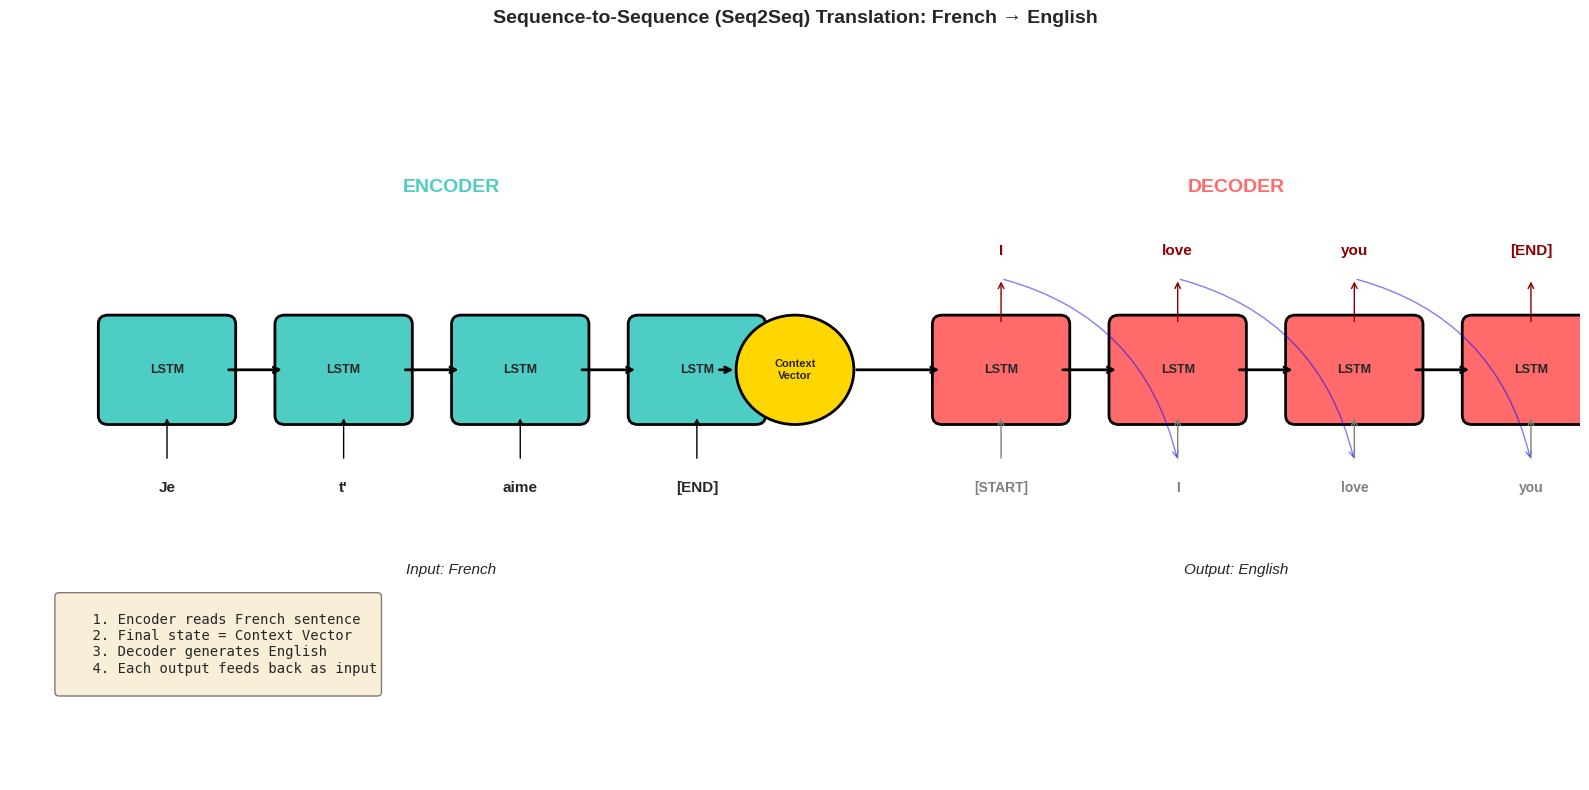


💡 Key Insight: The context vector is a BOTTLENECK!
   Long sentences are hard to compress into a single vector.
   This limitation led to the invention of ATTENTION...


In [ ]:
def visualize_seq2seq():
    """
    Visualize the encoder-decoder architecture for translation.
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # Colors
    encoder_color = '#4ECDC4'
    decoder_color = '#FF6B6B'
    context_color = '#FFD700'

    # Draw encoder cells
    encoder_words = ['Je', "t'", 'aime', '[END]']
    for i, word in enumerate(encoder_words):
        x = 1 + i * 1.8
        # Cell
        rect = FancyBboxPatch((x, 4), 1.2, 1, boxstyle="round,pad=0.1",
                              facecolor=encoder_color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x + 0.6, 4.5, 'LSTM', ha='center', va='center', fontsize=9, fontweight='bold')

        # Input word
        ax.text(x + 0.6, 3.2, word, ha='center', va='center', fontsize=11, fontweight='bold')
        ax.annotate('', xy=(x + 0.6, 4), xytext=(x + 0.6, 3.5),
                   arrowprops=dict(arrowstyle='->', color='black'))

        # Arrow to next cell
        if i < len(encoder_words) - 1:
            ax.annotate('', xy=(x + 1.8, 4.5), xytext=(x + 1.2, 4.5),
                       arrowprops=dict(arrowstyle='->', color='black', lw=2))

    # Context vector
    context_x = 7.5
    circle = plt.Circle((context_x + 0.5, 4.5), 0.6, color=context_color, ec='black', linewidth=2)
    ax.add_patch(circle)
    ax.text(context_x + 0.5, 4.5, 'Context\nVector', ha='center', va='center', fontsize=8, fontweight='bold')

    # Arrow from encoder to context
    ax.annotate('', xy=(context_x - 0.1, 4.5), xytext=(7.2, 4.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=2))

    # Arrow from context to decoder
    ax.annotate('', xy=(9.5, 4.5), xytext=(context_x + 1.1, 4.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=2))

    # Draw decoder cells
    decoder_words = ['[START]', 'I', 'love', 'you']
    output_words = ['I', 'love', 'you', '[END]']
    for i, (input_word, output_word) in enumerate(zip(decoder_words, output_words)):
        x = 9.5 + i * 1.8
        # Cell
        rect = FancyBboxPatch((x, 4), 1.2, 1, boxstyle="round,pad=0.1",
                              facecolor=decoder_color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x + 0.6, 4.5, 'LSTM', ha='center', va='center', fontsize=9, fontweight='bold')

        # Input word (below)
        ax.text(x + 0.6, 3.2, input_word, ha='center', va='center', fontsize=10,
               fontweight='bold', color='gray')
        ax.annotate('', xy=(x + 0.6, 4), xytext=(x + 0.6, 3.5),
                   arrowprops=dict(arrowstyle='->', color='gray'))

        # Output word (above)
        ax.text(x + 0.6, 5.8, output_word, ha='center', va='center', fontsize=11,
               fontweight='bold', color='darkred')
        ax.annotate('', xy=(x + 0.6, 5.5), xytext=(x + 0.6, 5),
                   arrowprops=dict(arrowstyle='->', color='darkred'))

        # Arrow to next cell
        if i < len(decoder_words) - 1:
            ax.annotate('', xy=(x + 1.8, 4.5), xytext=(x + 1.2, 4.5),
                       arrowprops=dict(arrowstyle='->', color='black', lw=2))

        # Feedback arrow (output to next input)
        if i < len(decoder_words) - 1:
            ax.annotate('', xy=(x + 2.4, 3.5), xytext=(x + 0.6, 5.5),
                       arrowprops=dict(arrowstyle='->', color='blue',
                                      connectionstyle='arc3,rad=-0.3', alpha=0.5))

    # Labels
    ax.text(4.5, 6.5, 'ENCODER', ha='center', va='center', fontsize=14,
           fontweight='bold', color=encoder_color)
    ax.text(4.5, 2.3, 'Input: French', ha='center', va='center', fontsize=11, style='italic')

    ax.text(12.5, 6.5, 'DECODER', ha='center', va='center', fontsize=14,
           fontweight='bold', color=decoder_color)
    ax.text(12.5, 2.3, 'Output: English', ha='center', va='center', fontsize=11, style='italic')

    # Title
    ax.set_title('Sequence-to-Sequence (Seq2Seq) Translation: French → English',
                fontsize=14, fontweight='bold', pad=20)

    # Legend box
    legend_text = """
    1. Encoder reads French sentence
    2. Final state = Context Vector
    3. Decoder generates English
    4. Each output feeds back as input
    """
    ax.text(0.5, 1, legend_text, fontsize=10, family='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

visualize_seq2seq()
print("\n💡 Key Insight: The context vector is a BOTTLENECK!")
print("   Long sentences are hard to compress into a single vector.")
print("   This limitation led to the invention of ATTENTION...")

---

## 2.4 Attention Mechanism: "Where Should I Look?" (2015)

### The Problem with Seq2Seq

The encoder must compress the **entire input** into a **single context vector**. This is like trying to summarize a whole book in one sentence - important details get lost!

### The Solution: Attention

Instead of using just one context vector, the decoder can **attend to different parts** of the input sequence at each step. It learns to **focus** on the relevant words!

```
           ATTENTION: "Where should I look?"

    ENCODER STATES:    h₁       h₂       h₃       h₄
    (French words)    "Je"     "t'"    "aime"   "[END]"
                       │        │        │        │
                       ▼        ▼        ▼        ▼
                    ┌────────────────────────────────┐
                    │     ATTENTION MECHANISM        │
                    │  "Which encoder states are     │
                    │   relevant for this output?"   │
                    └────────────────────────────────┘
                       │        │        │        │
                       ▼        ▼        ▼        ▼
    Attention       [0.1]    [0.05]   [0.8]    [0.05]  ← Weights sum to 1
    Weights:         │        │        │        │
                     └────────┴────┬───┴────────┘
                                   │
                                   ▼
                            Context Vector
                            (weighted sum)
                                   │
                                   ▼
                              DECODER
                            Outputs: "love"
```

### The Intuition: Query, Key, Value

Think of attention like a **search engine**:

| Component | Role | Example |
|-----------|------|---------|
| **Query (Q)** | "What am I looking for?" | Decoder state: "I need to translate this word" |
| **Key (K)** | "What information do I have?" | Encoder states: each word's representation |
| **Value (V)** | "What content should I retrieve?" | Same as keys (encoder states) |

**Attention Score** = How well does my query match each key?
**Context Vector** = Weighted average of values based on scores

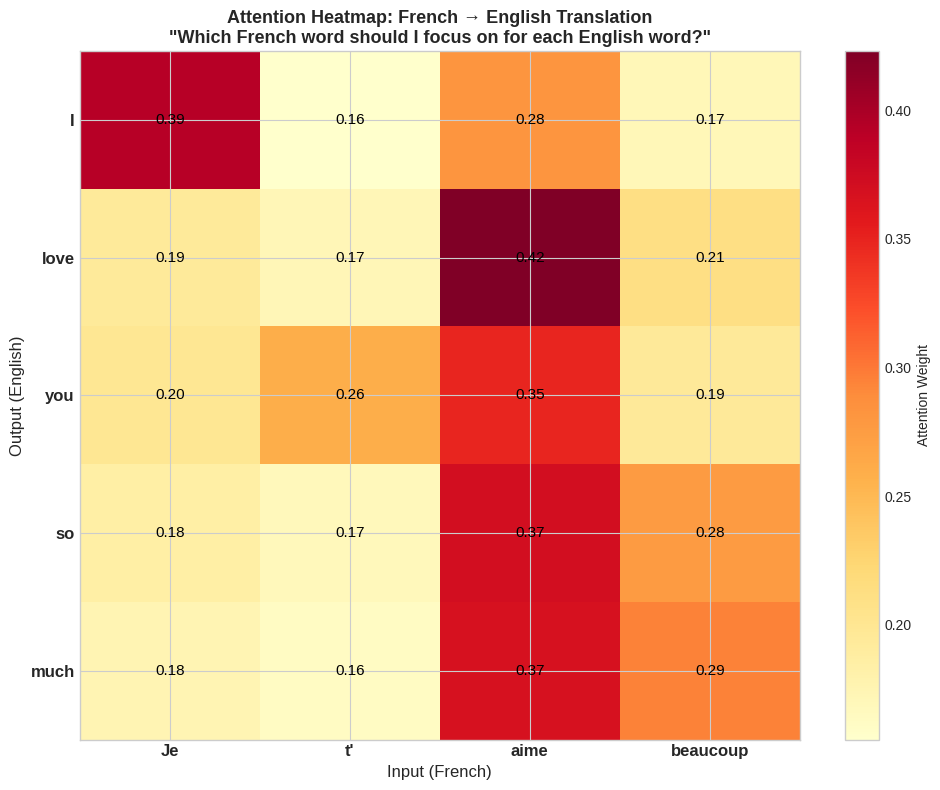


🔍 ATTENTION INTERPRETATION:
   'I' attends most to 'Je' (0.39)
   'love' attends most to 'aime' (0.42)
   'you' attends most to 'aime' (0.35)
   'so' attends most to 'aime' (0.37)
   'much' attends most to 'aime' (0.37)


In [ ]:
def softmax(x):
    """Softmax function - converts scores to probabilities (sum to 1)."""
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / exp_x.sum()

def attention(query: np.ndarray, keys: np.ndarray, values: np.ndarray):
    """
    Compute attention weights and context vector.

    Args:
        query: The decoder state (what we're looking for)
        keys: The encoder states (what we're searching through)
        values: The encoder states (what we retrieve)

    Returns:
        context: Weighted sum of values
        weights: Attention weights (where we looked)
    """
    # Step 1: Compute attention scores (dot product similarity)
    # How similar is my query to each key?
    scores = np.array([np.dot(query, k) for k in keys])

    # Step 2: Convert scores to probabilities (softmax)
    # Higher scores → higher weights
    weights = softmax(scores)

    # Step 3: Compute context vector (weighted sum of values)
    context = sum(w * v for w, v in zip(weights, values))

    return context, weights

def visualize_attention_mechanism():
    """Demonstrate attention with a translation example."""

    # Simulate encoder hidden states for French words
    french_words = ['Je', "t'", 'aime', 'beaucoup']
    encoder_states = np.array([
        [0.9, 0.1, 0.2, 0.8],   # "Je" (I)
        [0.2, 0.8, 0.1, 0.3],   # "t'" (you - object)
        [0.8, 0.9, 0.7, 0.2],   # "aime" (love)
        [0.3, 0.4, 0.9, 0.1],   # "beaucoup" (much/a lot)
    ])

    # Decoder states when generating English words
    english_words = ['I', 'love', 'you', 'so', 'much']
    decoder_queries = np.array([
        [0.85, 0.1, 0.25, 0.75],  # Looking for "I" → should attend to "Je"
        [0.75, 0.85, 0.65, 0.25], # Looking for "love" → should attend to "aime"
        [0.25, 0.9, 0.15, 0.35],  # Looking for "you" → should attend to "t'"
        [0.4, 0.5, 0.85, 0.15],   # Looking for "so" → attend to context
        [0.35, 0.45, 0.95, 0.1],  # Looking for "much" → should attend to "beaucoup"
    ])

    # Compute attention for each decoder step
    attention_matrix = []
    for query in decoder_queries:
        _, weights = attention(query, encoder_states, encoder_states)
        attention_matrix.append(weights)

    attention_matrix = np.array(attention_matrix)

    # Visualize as heatmap
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(attention_matrix, cmap='YlOrRd', aspect='auto')

    # Labels
    ax.set_xticks(range(len(french_words)))
    ax.set_xticklabels(french_words, fontsize=12, fontweight='bold')
    ax.set_yticks(range(len(english_words)))
    ax.set_yticklabels(english_words, fontsize=12, fontweight='bold')

    ax.set_xlabel('Input (French)', fontsize=12)
    ax.set_ylabel('Output (English)', fontsize=12)

    # Add values
    for i in range(len(english_words)):
        for j in range(len(french_words)):
            text = ax.text(j, i, f'{attention_matrix[i, j]:.2f}',
                          ha='center', va='center', fontsize=11,
                          color='white' if attention_matrix[i, j] > 0.5 else 'black')

    ax.set_title('Attention Heatmap: French → English Translation\n"Which French word should I focus on for each English word?"',
                fontsize=13, fontweight='bold')

    plt.colorbar(im, label='Attention Weight')
    plt.tight_layout()
    plt.show()

    # Print interpretation
    print("\n🔍 ATTENTION INTERPRETATION:")
    print("="*50)
    for i, (eng, att) in enumerate(zip(english_words, attention_matrix)):
        max_idx = np.argmax(att)
        print(f"   '{eng}' attends most to '{french_words[max_idx]}' ({att[max_idx]:.2f})")

visualize_attention_mechanism()

### Chapter 2 Summary

```
╔══════════════════════════════════════════════════════════════════════╗
║                      CHAPTER 2 RECAP                                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  RNNs        → Process sequences with hidden state memory            ║
║  Bi-RNNs     → Read both directions for full context                 ║
║  LSTMs/GRUs  → Gates solve vanishing gradients, remember longer      ║
║  Seq2Seq     → Encoder-decoder for translation, summarization        ║
║  Attention   → Focus on relevant parts of input at each step         ║
║                                                                       ║
║  REMAINING ISSUES:                                                    ║
║  • Still sequential processing (slow training!)                       ║
║  • Still some long-range dependency issues                           ║
║  • Complex architectures                                              ║
║                                                                       ║
║  NEXT: Transformers solve ALL of these! 🚀                            ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
```

---

# Chapter 3: The Transformer Revolution (2017)

## "Attention Is All You Need"

The Transformer paper changed everything. Its key insight:

> **We don't need RNNs at all! Attention alone is enough.**

This gave us:
- **Parallel processing** (much faster training!)
- **Better long-range dependencies** (attend to any position)
- **Foundation for GPT, BERT, ChatGPT, and all modern LLMs!**

## 3.1 Self-Attention: Every Word Looks at Every Other Word

### What is Self-Attention?

In regular attention, the **decoder** attends to the **encoder**.

In **self-attention**, a sequence attends to **itself**. Every word looks at every other word to understand context!

```
              SELF-ATTENTION: "The cat sat on the mat"

    "The"    "cat"    "sat"    "on"    "the"    "mat"
      │        │        │       │        │        │
      ▼        ▼        ▼       ▼        ▼        ▼
   ┌────────────────────────────────────────────────┐
   │              SELF-ATTENTION                    │
   │  Every word computes attention to every other  │
   │  word (including itself!)                      │
   └────────────────────────────────────────────────┘
      │        │        │       │        │        │
      ▼        ▼        ▼       ▼        ▼        ▼
    "The"    "cat"    "sat"    "on"    "the"    "mat"
   (enriched with context from all other words!)
   
   Now "cat" knows it's "sitting" and "on the mat"!
```

### The Query-Key-Value Framework

For self-attention, each word becomes **three things**:

1. **Query (Q)**: "What am I looking for?"
2. **Key (K)**: "What do I contain?"
3. **Value (V)**: "What information can I give?"

```
                For word "cat":
                
                    "cat"
                      │
           ┌─────────┼─────────┐
           ▼         ▼         ▼
        ┌─────┐  ┌─────┐  ┌─────┐
        │  Q  │  │  K  │  │  V  │
        └─────┘  └─────┘  └─────┘
           │         │         │
           ▼         ▼         ▼
      "What does  "I'm an  "Here's my
       cat want    animal"  info about
       to know?"            animals"
```

### The Self-Attention Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Don't worry! Let's break this down:

1. **QKᵀ**: Compute similarity between all query-key pairs (matrix multiplication)
2. **÷ √dₖ**: Scale down to prevent huge values (dₖ = dimension of keys)
3. **softmax**: Convert scores to probabilities (each row sums to 1)
4. **× V**: Use these weights to combine values

🔍 Self-Attention: Every word attends to every other word
   Notice how each row shows where that word 'looks'



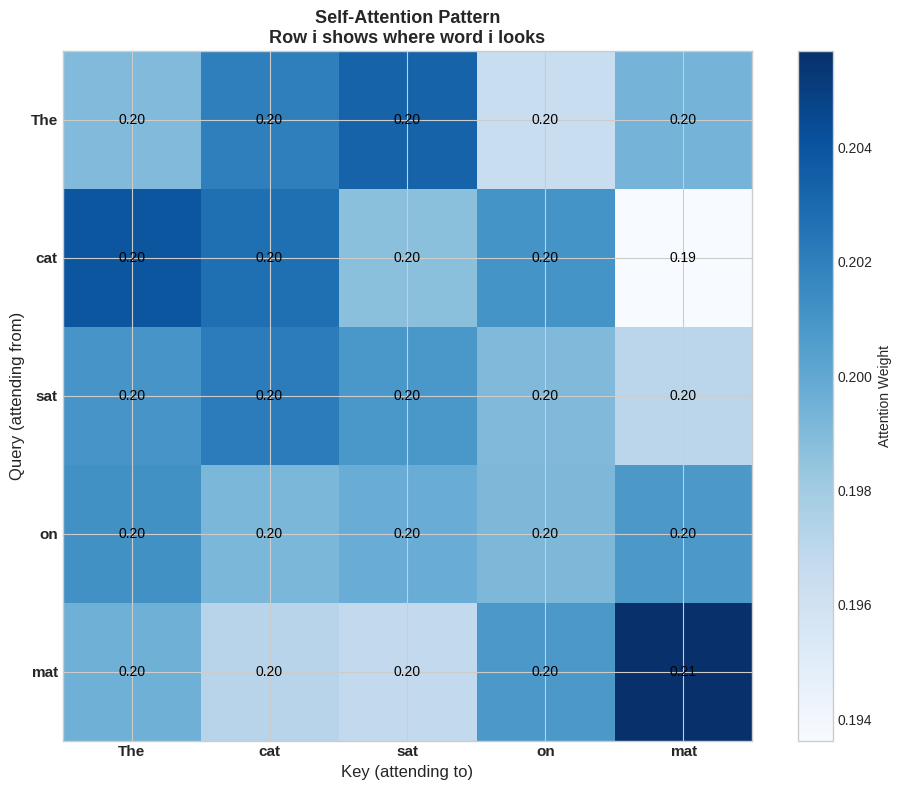

In [ ]:
class SelfAttention:
    """
    Self-Attention mechanism from scratch.

    This is the core building block of Transformers!
    """

    def __init__(self, d_model: int, d_k: int = None):
        """
        Initialize self-attention.

        Args:
            d_model: Dimension of input embeddings
            d_k: Dimension of queries and keys (default: d_model)
        """
        self.d_model = d_model
        self.d_k = d_k or d_model

        # Learnable weight matrices to create Q, K, V
        scale = 0.1
        self.W_q = np.random.randn(d_model, self.d_k) * scale  # Query weights
        self.W_k = np.random.randn(d_model, self.d_k) * scale  # Key weights
        self.W_v = np.random.randn(d_model, d_model) * scale   # Value weights

    def forward(self, X: np.ndarray, mask: np.ndarray = None):
        """
        Compute self-attention.

        Args:
            X: Input sequence (seq_len, d_model)
            mask: Optional mask for causal attention

        Returns:
            output: Attention output (seq_len, d_model)
            weights: Attention weights (seq_len, seq_len)
        """
        # Step 1: Create Q, K, V from input
        Q = X @ self.W_q  # (seq_len, d_k)
        K = X @ self.W_k  # (seq_len, d_k)
        V = X @ self.W_v  # (seq_len, d_model)

        # Step 2: Compute attention scores
        # scores[i,j] = how much should token i attend to token j?
        scores = Q @ K.T  # (seq_len, seq_len)

        # Step 3: Scale by sqrt(d_k) to prevent large values
        scores = scores / np.sqrt(self.d_k)

        # Step 4: Apply mask if provided (for decoder)
        if mask is not None:
            scores = scores + mask  # Mask is -inf for blocked positions

        # Step 5: Softmax to get attention weights
        weights = np.exp(scores - scores.max(axis=-1, keepdims=True))
        weights = weights / weights.sum(axis=-1, keepdims=True)

        # Step 6: Weighted sum of values
        output = weights @ V  # (seq_len, d_model)

        return output, weights

    def visualize(self, words: List[str], X: np.ndarray, title: str = "Self-Attention"):
        """Visualize attention patterns."""
        _, weights = self.forward(X)

        fig, ax = plt.subplots(figsize=(10, 8))

        im = ax.imshow(weights, cmap='Blues')

        ax.set_xticks(range(len(words)))
        ax.set_xticklabels(words, fontsize=11, fontweight='bold')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11, fontweight='bold')

        ax.set_xlabel('Key (attending to)', fontsize=12)
        ax.set_ylabel('Query (attending from)', fontsize=12)

        # Add values
        for i in range(len(words)):
            for j in range(len(words)):
                ax.text(j, i, f'{weights[i, j]:.2f}',
                       ha='center', va='center', fontsize=10,
                       color='white' if weights[i, j] > 0.5 else 'black')

        ax.set_title(f'{title}\nRow i shows where word i looks', fontsize=13, fontweight='bold')
        plt.colorbar(im, label='Attention Weight')
        plt.tight_layout()
        plt.show()

        return weights

# Create self-attention layer
self_attn = SelfAttention(d_model=8, d_k=8)

# Create embeddings for a sentence
words = ["The", "cat", "sat", "on", "mat"]
embeddings = np.random.randn(len(words), 8) * 0.5

# Add some structure so "cat" and "sat" are similar
embeddings[1, :4] = [0.8, 0.2, 0.9, 0.1]  # cat
embeddings[2, :4] = [0.7, 0.3, 0.85, 0.15]  # sat (similar to cat - verb agreement)
embeddings[4, :4] = [0.2, 0.8, 0.1, 0.9]  # mat (different)

print("🔍 Self-Attention: Every word attends to every other word")
print("   Notice how each row shows where that word 'looks'")
print()

weights = self_attn.visualize(words, embeddings, "Self-Attention Pattern")

---

## 3.2 Multi-Head Attention: Multiple Perspectives

### Why Multiple Heads?

One attention head learns **one type of relationship**. But language has many:
- Syntactic: subject-verb agreement
- Semantic: word meaning relationships
- Positional: nearby words
- Long-range: coreference (pronouns)

**Multi-head attention** runs multiple attention operations in parallel, each learning different patterns!

```
              MULTI-HEAD ATTENTION (4 heads)
              
    Input: "The cat sat on the mat"
                    │
       ┌───────────┼───────────┐
       │           │           │
       ▼           ▼           ▼
    ┌──────┐   ┌──────┐   ┌──────┐
    │Head 1│   │Head 2│   │Head 3│   ...
    │Syntax│   │Semant│   │Positn│
    └──────┘   └──────┘   └──────┘
       │           │           │
       └───────────┼───────────┘
                   │
               CONCATENATE
                   │
                   ▼
             Linear Layer
                   │
                   ▼
               Output
```

### What Different Heads Learn

| Head | Focus | Example Pattern |
|------|-------|-----------------|
| 1 | Syntax | Subject → Verb |
| 2 | Semantics | Noun → Related Noun |
| 3 | Position | Word → Previous Word |
| 4 | Long-range | Pronoun → Referent |

🎯 Multi-Head Attention: 4 different perspectives!
   Each head learns to focus on different relationships



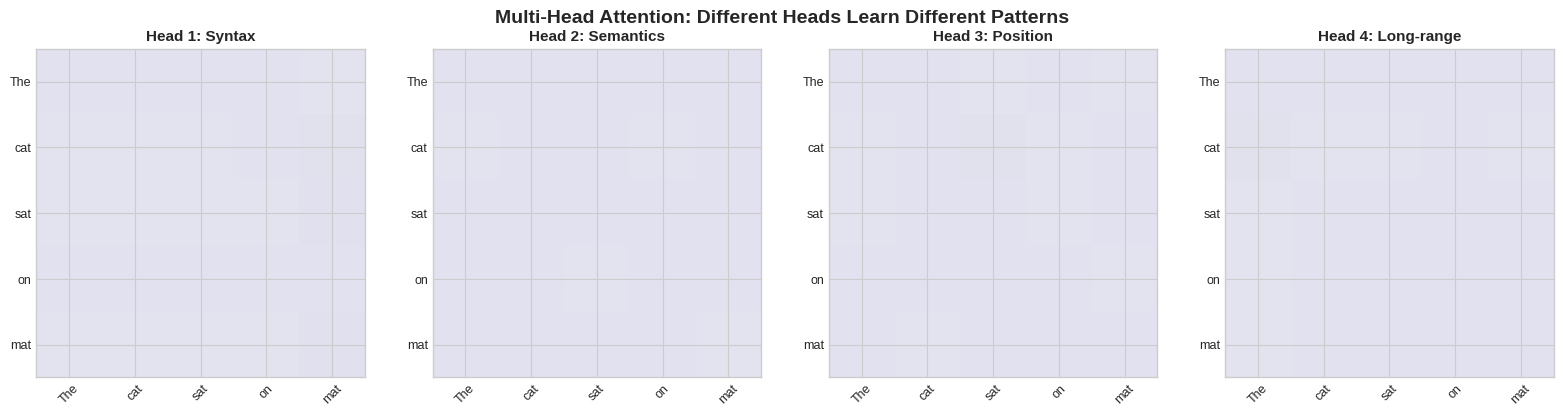

In [ ]:
class MultiHeadAttention:
    """
    Multi-Head Attention: Multiple attention heads in parallel.

    Each head can learn different types of relationships!
    """

    def __init__(self, d_model: int, n_heads: int):
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # Dimension per head

        # Create multiple attention heads
        self.heads = [SelfAttention(d_model, self.d_k) for _ in range(n_heads)]

        # Output projection
        self.W_o = np.random.randn(d_model, d_model) * 0.1

    def forward(self, X: np.ndarray, mask: np.ndarray = None):
        """Run all heads and concatenate."""
        head_outputs = []
        all_weights = []

        for head in self.heads:
            output, weights = head.forward(X, mask)
            head_outputs.append(output)
            all_weights.append(weights)

        # Concatenate and project (simplified - just average for demo)
        concat = np.mean(head_outputs, axis=0)
        output = concat @ self.W_o

        return output, all_weights

    def visualize_heads(self, words: List[str], X: np.ndarray):
        """Visualize all attention heads side by side."""
        _, all_weights = self.forward(X)

        n_heads = len(all_weights)
        cols = min(4, n_heads)
        rows = (n_heads + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        if n_heads == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = axes.reshape(1, -1)

        head_names = ['Syntax', 'Semantics', 'Position', 'Long-range', 'Pattern 5', 'Pattern 6', 'Pattern 7', 'Pattern 8']

        for idx, weights in enumerate(all_weights):
            row, col = idx // cols, idx % cols
            ax = axes[row, col]

            im = ax.imshow(weights, cmap='Purples', vmin=0, vmax=1)
            ax.set_xticks(range(len(words)))
            ax.set_xticklabels(words, fontsize=9, rotation=45)
            ax.set_yticks(range(len(words)))
            ax.set_yticklabels(words, fontsize=9)
            ax.set_title(f'Head {idx+1}: {head_names[idx]}', fontsize=11, fontweight='bold')

        # Hide unused subplots
        for idx in range(n_heads, rows * cols):
            row, col = idx // cols, idx % cols
            axes[row, col].axis('off')

        fig.suptitle('Multi-Head Attention: Different Heads Learn Different Patterns',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Create multi-head attention with 4 heads
multi_attn = MultiHeadAttention(d_model=8, n_heads=4)

print("🎯 Multi-Head Attention: 4 different perspectives!")
print("   Each head learns to focus on different relationships")
print()

multi_attn.visualize_heads(words, embeddings)

---

## 3.3 Positional Encodings: Where Am I?

### The Problem: Transformers Have No Sense of Order!

Unlike RNNs which process words one-by-one, Transformers process all words **at once** (in parallel). This is fast, but there's a problem:

> "The cat sat on the mat" and "mat the on sat cat The"
> look the SAME to self-attention! (just shuffled)

### The Solution: Add Position Information

We add special **positional encodings** to each word embedding that tell the model "you are at position X."

```
           POSITIONAL ENCODING
           
    Word:       "The"    "cat"    "sat"    "on"    "mat"
    Position:     0        1        2        3        4
                  │        │        │        │        │
                  ▼        ▼        ▼        ▼        ▼
    Word       [0.2,    [0.8,    [0.5,    [0.1,    [0.3,
    Embedding   0.5,     0.2,     0.4,     0.9,     0.7,
                ...]     ...]     ...]     ...]     ...]
                  +        +        +        +        +
    Position   [1.0,    [0.5,    [-0.2,   [-0.8,   [-1.0,
    Encoding    0.0,     0.8,     0.9,     0.4,    -0.4,
                ...]     ...]     ...]     ...]     ...]
                  =        =        =        =        =
    Final      [1.2,    [1.3,    [0.3,    [-0.7,   [-0.7,
    Input       0.5,     1.0,     1.3,     1.3,     0.3,
                ...]     ...]     ...]     ...]     ...]
```

### Sinusoidal Encodings: The Original Approach

The original Transformer used sine and cosine functions at different frequencies:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

**Why sinusoids?**
- Creates unique pattern for each position
- Model can learn relative positions (PE[pos+k] is a linear function of PE[pos])
- Works for any sequence length!

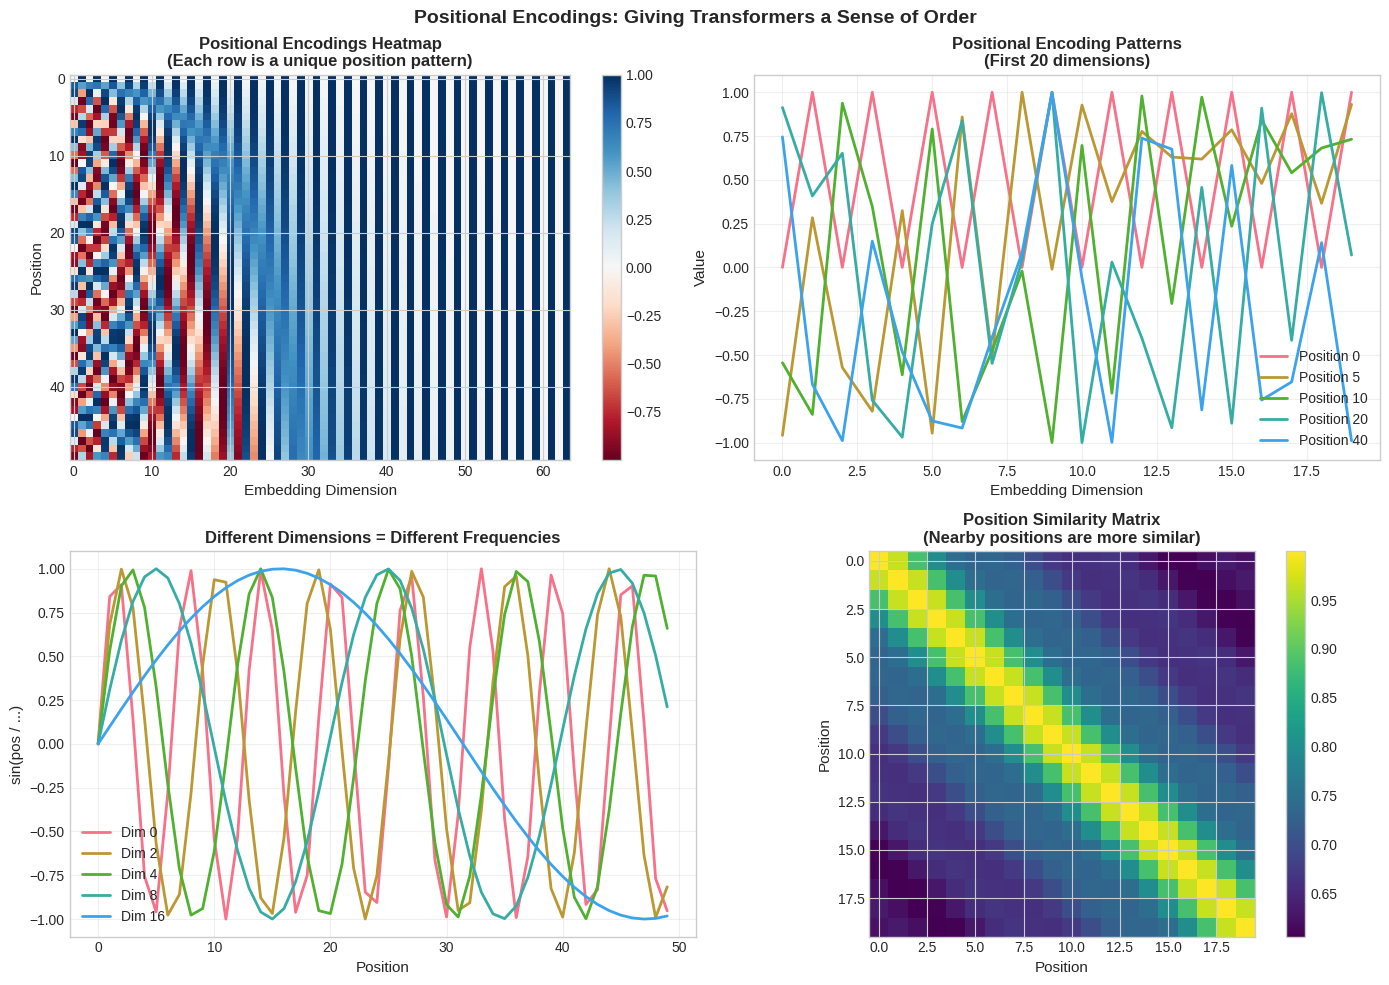


💡 Key Insight: Positional encodings let Transformers know WHERE words are!
   Without them, 'dog bites man' and 'man bites dog' would look identical.


In [ ]:
def get_positional_encoding(max_len: int, d_model: int) -> np.ndarray:
    """
    Generate sinusoidal positional encodings.

    These give each position a unique "fingerprint" that the model
    can learn to use for understanding word order.
    """
    pe = np.zeros((max_len, d_model))
    position = np.arange(max_len).reshape(-1, 1)

    # Create the division term for different frequencies
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # Even dimensions use sin, odd dimensions use cos
    pe[:, 0::2] = np.sin(position * div_term)  # Even indices
    pe[:, 1::2] = np.cos(position * div_term)  # Odd indices

    return pe

def visualize_positional_encodings():
    """Visualize how positional encodings look."""
    max_len = 50
    d_model = 64

    pe = get_positional_encoding(max_len, d_model)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Heatmap of all encodings
    ax1 = axes[0, 0]
    im = ax1.imshow(pe, aspect='auto', cmap='RdBu')
    ax1.set_xlabel('Embedding Dimension', fontsize=11)
    ax1.set_ylabel('Position', fontsize=11)
    ax1.set_title('Positional Encodings Heatmap\n(Each row is a unique position pattern)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax1)

    # Plot 2: A few positions compared
    ax2 = axes[0, 1]
    positions_to_show = [0, 5, 10, 20, 40]
    for pos in positions_to_show:
        ax2.plot(pe[pos, :20], label=f'Position {pos}', linewidth=2)
    ax2.set_xlabel('Embedding Dimension', fontsize=11)
    ax2.set_ylabel('Value', fontsize=11)
    ax2.set_title('Positional Encoding Patterns\n(First 20 dimensions)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Sin waves at different frequencies
    ax3 = axes[1, 0]
    dims = [0, 2, 4, 8, 16]
    for d in dims:
        ax3.plot(pe[:, d], label=f'Dim {d}', linewidth=2)
    ax3.set_xlabel('Position', fontsize=11)
    ax3.set_ylabel('sin(pos / ...)', fontsize=11)
    ax3.set_title('Different Dimensions = Different Frequencies', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Similarity matrix (to show relative positions can be learned)
    ax4 = axes[1, 1]
    # Compute cosine similarity between positions
    pe_norm = pe / (np.linalg.norm(pe, axis=1, keepdims=True) + 1e-8)
    similarity = pe_norm @ pe_norm.T

    im = ax4.imshow(similarity[:20, :20], cmap='viridis')
    ax4.set_xlabel('Position', fontsize=11)
    ax4.set_ylabel('Position', fontsize=11)
    ax4.set_title('Position Similarity Matrix\n(Nearby positions are more similar)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax4)

    fig.suptitle('Positional Encodings: Giving Transformers a Sense of Order', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_positional_encodings()

print("\n💡 Key Insight: Positional encodings let Transformers know WHERE words are!")
print("   Without them, 'dog bites man' and 'man bites dog' would look identical.")

---

## 3.4 The Complete Transformer Architecture

### Putting It All Together

```
                    THE TRANSFORMER ARCHITECTURE
                    
                    ╔═══════════════════════════════════════╗
                    ║             ENCODER                   ║
                    ╠═══════════════════════════════════════╣
    Input           ║                                       ║
   Tokens    →      ║  ┌─────────────────────────────────┐  ║
      │             ║  │     Multi-Head Self-Attention   │  ║
      ▼             ║  └─────────────────────────────────┘  ║
  Embedding         ║                  │                    ║
      +             ║                  ▼                    ║
  Positional        ║  ┌─────────────────────────────────┐  ║
      │             ║  │       Add & Layer Norm          │  ║
      ▼             ║  └─────────────────────────────────┘  ║
   ┌────┐           ║                  │                    ║
   │ ×N │           ║                  ▼                    ║
   │    │           ║  ┌─────────────────────────────────┐  ║
   │    │           ║  │    Feed-Forward Network         │  ║
   │    │           ║  └─────────────────────────────────┘  ║
   │    │           ║                  │                    ║
   │    │           ║                  ▼                    ║
   │    │           ║  ┌─────────────────────────────────┐  ║
   │    │           ║  │       Add & Layer Norm          │  ║
   │    │           ║  └─────────────────────────────────┘  ║
   └────┘           ╚═══════════════════════════════════════╝
                                       │
                                       │ Encoder Output
                                       ▼
                    ╔═══════════════════════════════════════╗
                    ║             DECODER                   ║
                    ╠═══════════════════════════════════════╣
    Output          ║  ┌─────────────────────────────────┐  ║
   Tokens    →      ║  │  Masked Multi-Head Attention    │  ║
      │             ║  │     (Can't see future!)         │  ║
      ▼             ║  └─────────────────────────────────┘  ║
  Embedding         ║                  │                    ║
      +             ║                  ▼                    ║
  Positional        ║  ┌─────────────────────────────────┐  ║
      │             ║  │  Cross-Attention to Encoder     │  ║
      ▼             ║  └─────────────────────────────────┘  ║
   ┌────┐           ║                  │                    ║
   │ ×N │           ║                  ▼                    ║
   │    │           ║  ┌─────────────────────────────────┐  ║
   │    │           ║  │    Feed-Forward Network         │  ║
   │    │           ║  └─────────────────────────────────┘  ║
   └────┘           ╚═══════════════════════════════════════╝
                                       │
                                       ▼
                              Linear + Softmax
                                       │
                                       ▼
                              Output Probabilities
```

### Key Components Explained

| Component | Purpose |
|-----------|---------|
| **Multi-Head Self-Attention** | Each position attends to all other positions |
| **Masked Self-Attention** | Decoder can only see past tokens (no cheating!) |
| **Cross-Attention** | Decoder attends to encoder output |
| **Feed-Forward Network** | 2-layer MLP applied to each position |
| **Add & Layer Norm** | Residual connections + normalization for stable training |
| **×N** | Stack multiple layers (6-12 typically) |

### Why Transformers Won

```
╔══════════════════════════════════════════════════════════════════════╗
║                    TRANSFORMER ADVANTAGES                             ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  1. PARALLELIZATION: Process all tokens at once! 🚀                   ║
║     - RNN: O(n) sequential steps                                     ║
║     - Transformer: O(1) parallel steps (with GPU)                    ║
║                                                                       ║
║  2. LONG-RANGE DEPENDENCIES: Direct path between any two positions   ║
║     - RNN: Info must flow through all intermediate steps             ║
║     - Transformer: Direct attention, constant path length            ║
║                                                                       ║
║  3. SCALABILITY: Just add more layers and parameters!                ║
║     - Enabled GPT-3 (175B), GPT-4 (rumored 1.7T)                     ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
```

---

# Chapter 4: The Rise of Large Language Models (LLMs)

## What Makes a Model "Large"?

**LLM** stands for **Large Language Model** - deep learning models with:
- **Hundreds of millions to trillions of parameters**
- **Trained on massive text corpora** (books, websites, code)
- **Capture complex language patterns and world knowledge**

```
                    MODEL SIZE EVOLUTION

    2018: GPT-1          117 Million params      📒
    2019: GPT-2          1.5 Billion params      📚
    2020: GPT-3          175 Billion params      📚📚📚📚📚📚📚📚
    2023: GPT-4          ~1.7 Trillion params    🏛️🏛️🏛️🏛️🏛️🏛️🏛️🏛️🏛️🏛️...
```

---

## 4.1 GPT: The Decoder-Only Approach

### GPT = Generative Pre-trained Transformer

GPT (2018) was the **first LLM**. Its key innovations:

1. **Decoder-only architecture** (no encoder!)
2. **Pre-training** on massive text data
3. **Next-word prediction** as the training task

```
              GPT: DECODER-ONLY ARCHITECTURE
              
    "The    cat    sat    on    the"
      │       │      │      │      │
      ▼       ▼      ▼      ▼      ▼
   ┌────────────────────────────────────┐
   │     MASKED SELF-ATTENTION          │
   │  (Can only look at PAST tokens)    │
   │                                    │
   │  "The" sees: [The]                 │
   │  "cat" sees: [The, cat]            │
   │  "sat" sees: [The, cat, sat]       │
   │  ...                               │
   └────────────────────────────────────┘
                    │
                    ▼
              ┌──────────┐
              │  Linear  │
              │ + Softmax│
              └──────────┘
                    │
                    ▼
              Predict: "mat" (next word)
```

### The Pre-training Task: Next Word Prediction

GPT learns by predicting the next word in billions of sentences:

```
Input:  "The quick brown fox"
Target: "jumps"

Input:  "In the year 2024,"
Target: "artificial"

Input:  "def fibonacci(n):"
Target: "return"
```

This simple task teaches GPT:
- Grammar and syntax
- Facts and knowledge
- Reasoning patterns
- Code structure
- And much more!

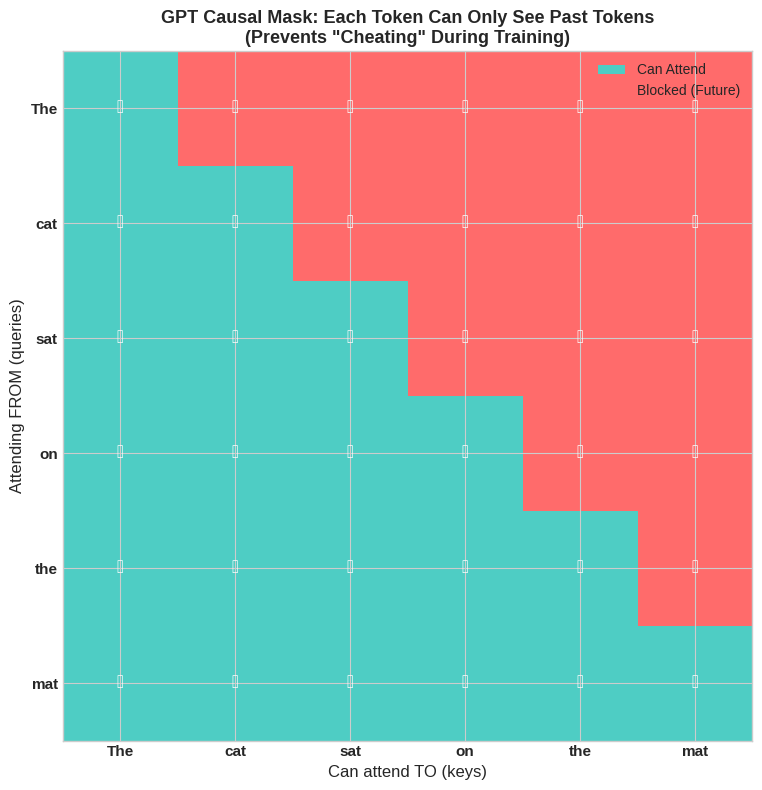


💡 Example: When predicting after 'sat', the model can see:
   'The', 'cat', 'sat' ✓
   'on', 'the', 'mat' ✗ (future - blocked!)


In [ ]:
def visualize_causal_mask(seq_len: int = 6):
    """
    Visualize the causal (look-ahead) mask used in GPT.

    This mask prevents tokens from seeing future tokens during training.
    """
    words = ["The", "cat", "sat", "on", "the", "mat"][:seq_len]

    # Create causal mask: 1 where we CAN attend, 0 where we CANNOT
    mask = np.tril(np.ones((seq_len, seq_len)))

    fig, ax = plt.subplots(figsize=(10, 8))

    # Use a custom colormap
    colors = ['#FF6B6B', '#4ECDC4']  # Red = blocked, Teal = allowed
    cmap = plt.cm.colors.ListedColormap(colors)

    im = ax.imshow(mask, cmap=cmap)

    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(words, fontsize=11, fontweight='bold')
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(words, fontsize=11, fontweight='bold')

    ax.set_xlabel('Can attend TO (keys)', fontsize=12)
    ax.set_ylabel('Attending FROM (queries)', fontsize=12)

    # Add text annotations
    for i in range(seq_len):
        for j in range(seq_len):
            if mask[i, j] == 1:
                ax.text(j, i, '✓', ha='center', va='center', fontsize=14, color='white')
            else:
                ax.text(j, i, '✗', ha='center', va='center', fontsize=14, color='white')

    ax.set_title('GPT Causal Mask: Each Token Can Only See Past Tokens\n(Prevents "Cheating" During Training)',
                fontsize=13, fontweight='bold')

    # Legend
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor=colors[1], label='Can Attend'),
        plt.Rectangle((0,0),1,1, facecolor=colors[0], label='Blocked (Future)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

    print("\n💡 Example: When predicting after 'sat', the model can see:")
    print("   'The', 'cat', 'sat' ✓")
    print("   'on', 'the', 'mat' ✗ (future - blocked!)")

visualize_causal_mask()

---

## 4.2 BERT: The Encoder-Only Approach

### BERT = Bidirectional Encoder Representations from Transformers

While GPT looks only at past tokens, BERT looks at **all tokens** (both directions). This makes it excellent for understanding, not generating.

```
              GPT vs BERT: DIRECTION OF ATTENTION
              
    GPT (Decoder-Only):              BERT (Encoder-Only):
    ─────────────────                ─────────────────
    
    "The cat sat"                    "The cat sat"
       │   │   │                        │   │   │
       ▼   ▼   ▼                        ▼   ▼   ▼
    ┌───────────────┐               ┌───────────────┐
    │ → → → → → → → │               │ ← → ← → ← → │
    │ Can see PAST  │               │ Can see ALL   │
    │ only          │               │ tokens!       │
    └───────────────┘               └───────────────┘
          │                               │
          ▼                               ▼
    Good for:                       Good for:
    • Text generation               • Understanding
    • Completion                    • Classification
    • Chatbots                      • Q&A
```

### BERT's Pre-training Task: Masked Language Modeling (MLM)

BERT learns by filling in **masked** (hidden) words:

```
Input:  "The cat [MASK] on the mat"
Target: "sat"

Input:  "Paris is the [MASK] of France"
Target: "capital"
```

This forces BERT to:
- Understand context from **both directions**
- Build rich representations of meaning
- Learn relationships between words

---

## 4.3 Other Important LLMs

### XLNet: Best of Both Worlds

XLNet (2019) combines GPT's autoregressive training with BERT's bidirectional context using **permutation language modeling**:

```
    Original: "The cat sat"
    
    XLNet trains on ALL permutations:
    • "The" → predict "cat" → predict "sat"
    • "cat" → predict "The" → predict "sat"
    • "sat" → predict "The" → predict "cat"
    ...
    
    Result: Learns to use context from ANY direction!
```

### T5: Text-to-Text Transfer Transformer

T5 (2019) frames **every NLP task** as text-to-text:

```
    TRANSLATION:
    Input:  "translate English to German: Hello world"
    Output: "Hallo Welt"
    
    SUMMARIZATION:
    Input:  "summarize: [long article...]"
    Output: "[short summary]"
    
    SENTIMENT:
    Input:  "sentiment: This movie was amazing!"
    Output: "positive"
```

**One model, any task!**

---

## 4.4 Making LLMs Efficient

### Knowledge Distillation: Teaching Small Models

Large models are slow and expensive. **Knowledge distillation** creates smaller, faster models:

```
    TEACHER (Large)           STUDENT (Small)
    ┌─────────────┐          ┌─────────────┐
    │  BERT-Large │   →→→    │ DistilBERT  │
    │  340M params│  teach   │  66M params │
    └─────────────┘          └─────────────┘
           │                        │
           ▼                        ▼
      Slow but                Fast and
      accurate                almost as good!
```

### LoRA: Low-Rank Adaptation

**LoRA** (2021) is a revolutionary fine-tuning technique:

```
    Traditional Fine-tuning:         LoRA Fine-tuning:
    ─────────────────────           ─────────────────
    
    Update ALL weights              Freeze original weights
    (billions of params!)           Add small "adapter" matrices
                                    
    ┌─────────────────┐             ┌─────────────────┐
    │   W (original)  │             │   W (frozen)    │
    │                 │             │ + ΔW = A × B    │
    │  175B updates!  │             │   (tiny!)       │
    └─────────────────┘             └─────────────────┘
    
    💰 Expensive                    💰 ~10,000× cheaper!
```

LoRA freezes the pre-trained model and adds small trainable matrices, reducing fine-tuning cost dramatically!

---

# Chapter 5: Human Alignment - Making AI Helpful & Safe

## 5.1 The Hallucination Problem

### What is Hallucination?

LLMs sometimes generate **confident but completely wrong** information:

```
    User: "Who was the first person to walk on Mars?"
    
    GPT-3: "Neil Armstrong was the first person to walk on Mars
           in 1969 during the Apollo 11 mission."
    
    ⚠️ HALLUCINATION! No one has walked on Mars!
```

### Why Do LLMs Hallucinate?

1. **Training objective**: Predict likely text, not truthful text
2. **No fact-checking**: Models don't verify against knowledge bases
3. **Pattern completion**: "Neil Armstrong + first + walk" → generates familiar pattern
4. **No uncertainty**: Models don't say "I don't know"

```
╔══════════════════════════════════════════════════════════════════╗
║                 THE HALLUCINATION PROBLEM                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  LLMs are trained to generate FLUENT text                        ║
║  NOT necessarily TRUTHFUL text!                                  ║
║                                                                   ║
║  "GPT-3's objective was to predict likely sentences              ║
║   but there is no notion of correctness or factual bias"         ║
║                                                                   ║
║  Humans want: coherent, informative, TRUSTWORTHY outputs         ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
```

---

## 5.2 RLHF: Reinforcement Learning from Human Feedback

### The InstructGPT Breakthrough (2022)

OpenAI's InstructGPT showed how to align LLMs with human values using **RLHF**:

```
        THE RLHF PIPELINE
        
    Step 1: COLLECT DEMONSTRATIONS
    ────────────────────────────
    Human labelers write ideal responses to prompts
    
    Prompt: "Explain quantum physics simply"
    Human: [Writes a helpful, accurate explanation]
    
    
    Step 2: TRAIN REWARD MODEL
    ────────────────────────────
    Humans rank multiple model outputs
    
    Response A: [Technical jargon]     → Rank: 3rd
    Response B: [Clear explanation]    → Rank: 1st ⭐
    Response C: [Wrong information]    → Rank: 4th
    
    Train a model to predict human preferences!
    
    
    Step 3: OPTIMIZE WITH RL
    ────────────────────────────
    Fine-tune GPT to maximize reward model score
    
    GPT output → Reward Model → Score → Update GPT
                     ↑
              (predicts human preference)
```

---

## 5.3 ChatGPT and GPT-4: The AI Revolution

### From InstructGPT to ChatGPT

**ChatGPT** (November 2022) built on InstructGPT but was specifically trained for **conversations**:

| InstructGPT | ChatGPT |
|-------------|---------|
| Follow single instructions | Multi-turn conversations |
| Task completion | Engaging dialogue |
| Less context awareness | Remembers conversation history |

### GPT-4: The State of the Art

**GPT-4** (March 2023) brought major improvements:

```
╔══════════════════════════════════════════════════════════════════════╗
║                         GPT-4 IMPROVEMENTS                            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  📊 SIZE: Order of magnitude larger than GPT-3                       ║
║  🎯 ACCURACY: More truthful, fewer hallucinations                    ║
║  🎨 CREATIVITY: Better at creative tasks                             ║
║  🤝 RELIABILITY: More consistent responses                           ║
║  🖼️ MULTIMODAL: Can understand images!                               ║
║  🔒 SAFETY: Better at refusing harmful requests                      ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
```

### Zero-Shot and Few-Shot Learning

RLHF-trained models can perform tasks they were never explicitly trained for:

```
    ZERO-SHOT (no examples):
    ────────────────────────
    "Translate to French: Hello"
    → "Bonjour"
    
    FEW-SHOT (a few examples):
    ────────────────────────
    "Here's how to format:
     Input: red, Output: rojo
     Input: blue, Output: azul
     Input: green, Output: ???"
    → "verde"
```

This is **emergent behavior** - the model learned these abilities from training, not explicit programming!

---

## 5.4 The Future: Questions and Concerns

### Open Questions

```
╔══════════════════════════════════════════════════════════════════════╗
║              DEEP QUESTIONS ABOUT LLMs                                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  🔮 BLACK BOX: We can ask questions, but can't truly understand     ║
║     what's happening inside billions of parameters                   ║
║                                                                       ║
║  🧠 CONSCIOUSNESS? Does exhibiting empathy mean feeling it?          ║
║     Or just pattern matching to "sound human"?                       ║
║                                                                       ║
║  🤥 DECEPTION: Can models lie? If they can fool us,                  ║
║     how would we know?                                               ║
║                                                                       ║
║  🌐 SAFETY: What happens when AI connects to the internet,           ║
║     makes decisions, interacts with the real world?                  ║
║                                                                       ║
║  "This might be the first time in human history when we              ║
║   encounter an entity which might be smarter than a single human"   ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
```

---

# Summary: 10 Years of NLP Breakthroughs

## The Complete Timeline

```
 2013     2014      2015      2017      2018      2019      2020      2022      2023
   │        │         │         │         │         │         │         │         │
   ▼        ▼         ▼         ▼         ▼         ▼         ▼         ▼         ▼
┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐
│Word │  │Seq2 │  │Atten│  │Trans│  │BERT │  │GPT-2│  │GPT-3│  │Chat │  │GPT-4│
│2Vec │  │Seq  │  │tion │  │former│  │     │  │XLNet│  │T5   │  │GPT  │  │     │
└─────┘  └─────┘  └─────┘  └─────┘  └─────┘  └─────┘  └─────┘  └─────┘  └─────┘
   │        │         │         │         │         │         │         │         │
Words    RNNs      Focus on   "Attention   Pre-     Scale    175B     RLHF    SOTA
become   process   relevant   Is All      training  up!      params!  Human   Multi
vectors  sequences parts      You Need"   works!                       Align   modal
```

## The 50 Key Concepts We Covered

```
╔═══════════════════════════════════════════════════════════════════════════════╗
║                         MASTER CONCEPT LIST                                    ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  CHAPTER 1: BASICS                    CHAPTER 4: LLMs                         ║
║  ├── Tokenization                     ├── GPT (Decoder-only)                  ║
║  ├── Word Embeddings                  ├── BERT (Encoder-only)                 ║
║  ├── Word2Vec                         ├── Masked Language Modeling            ║
║  └── Vocabulary                       ├── XLNet (Permutation LM)              ║
║                                       ├── T5 (Text-to-Text)                   ║
║  CHAPTER 2: SEQUENTIAL                ├── Knowledge Distillation              ║
║  ├── RNNs                             ├── LoRA (Low-Rank Adaptation)          ║
║  ├── Bidirectional RNNs               ├── Few-shot Learning                   ║
║  ├── LSTMs (Gates!)                   └── Zero-shot Learning                  ║
║  ├── GRUs                                                                     ║
║  ├── Vanishing Gradients              CHAPTER 5: ALIGNMENT                    ║
║  ├── Encoder-Decoder                  ├── Hallucination                       ║
║  ├── Seq2Seq                          ├── Reward Modeling                     ║
║  └── Attention Mechanism              ├── RLHF                                ║
║                                       ├── InstructGPT                         ║
║  CHAPTER 3: TRANSFORMERS              ├── ChatGPT                             ║
║  ├── Self-Attention                   ├── GPT-4                               ║
║  ├── Query, Key, Value                └── AI Safety                           ║
║  ├── Multi-Head Attention                                                     ║
║  ├── Positional Encoding                                                      ║
║  ├── Encoder (BERT-style)                                                     ║
║  ├── Decoder (GPT-style)                                                      ║
║  └── Parallelization                                                          ║
║                                                                                ║
╚═══════════════════════════════════════════════════════════════════════════════╝
```

## Key Takeaways

1. **Words → Vectors**: Embeddings capture meaning
2. **Order Matters**: RNNs/LSTMs process sequences
3. **Attention Is All You Need**: Transformers replaced RNNs
4. **Scale Matters**: Bigger models = better performance
5. **Pre-training Works**: Train once, use everywhere
6. **Alignment Is Crucial**: RLHF makes AI helpful and safe

## What's Next?

This is an exciting time in AI! Areas to explore:
- **Multimodal AI**: Models that see, hear, and read
- **Efficient AI**: Making models smaller and faster
- **Reasoning**: Teaching models to think step-by-step
- **Safety**: Ensuring AI remains beneficial

---

## Congratulations! 🎉

You've completed a journey through 10 years of NLP history. You now understand:
- How computers process language
- The evolution from RNNs to Transformers
- How ChatGPT and GPT-4 work
- The challenges of AI alignment

**Keep learning, keep experimenting, and stay curious!**